# **Navigating the Data Analyst Job Market: An Evidence-Based Guide for Aspiring Data Analysts**
<pre>📊 Dataset: glassdoow-raw.xlsx       🐍 Language: Python       📍 Scope: U.S. Job Market</pre>

---

## 💻 **A Question From the Job Market**

A user on **r/phcareers** shared their frustration about trying to break into the Data Analyst job market.

> 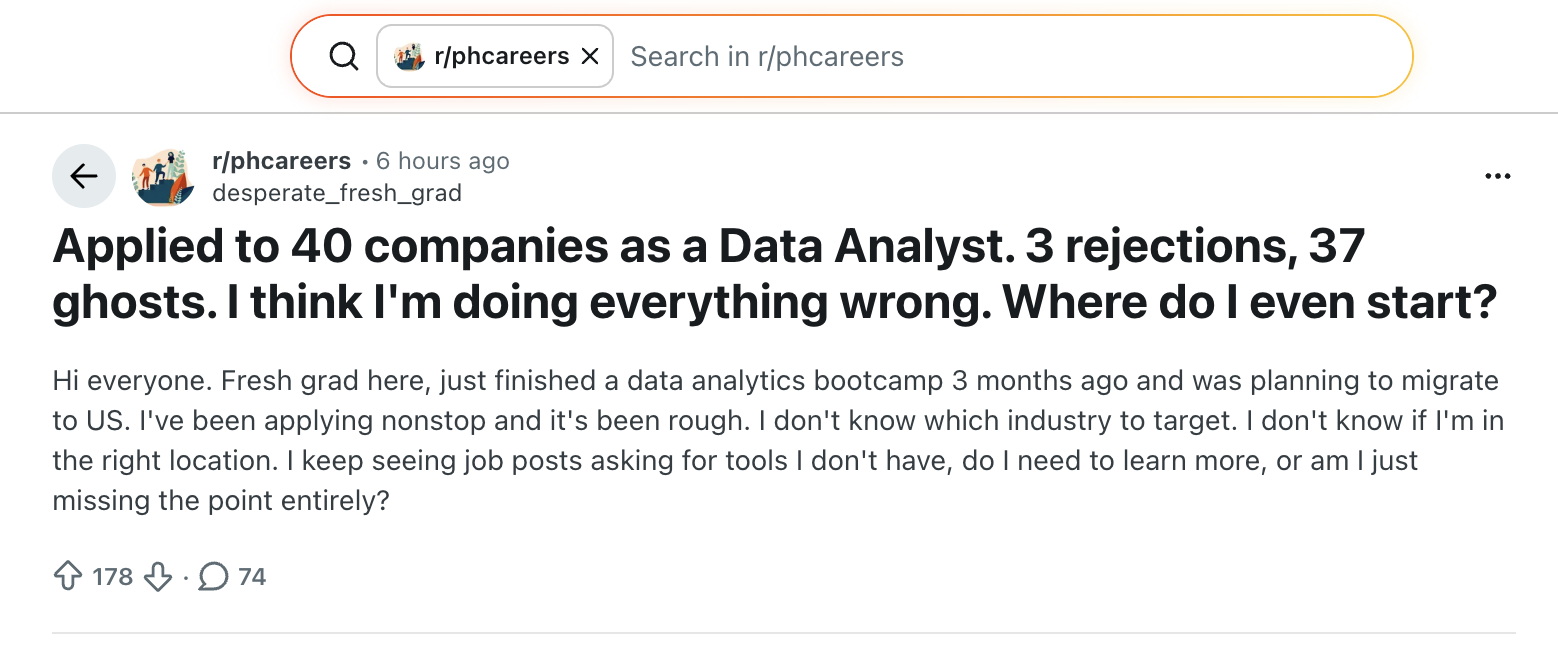

The post reflects a challenge that is extremely common for aspiring Data Analysts entering the job market today.

* Which industries actually hire the most Data Analysts?  
* Does location significantly impact job opportunities and salary?  
* Which technical skills are truly required at different career stages?

These questions reflect a broader challenge in the job market: **there is plenty of advice, but little data-driven guidance.**

## 💬 **A Few Hours Later, We Decided to Respond**

Instead of offering generic advice, we analyzed real job market data to answer these questions directly.

> 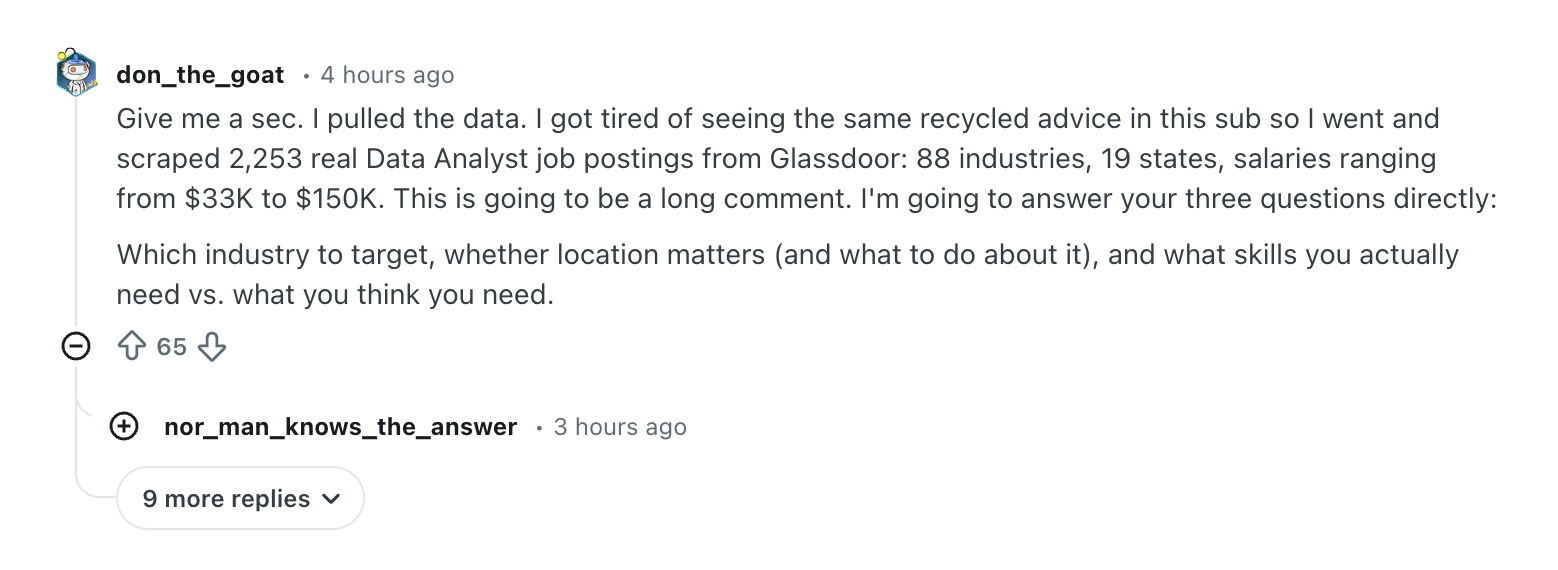

We collected and analyzed **2,253 Data Analyst job postings from Glassdoor**, covering:

- **88 industries** across the U.S. job market
- **19 states** with varying levels of demand and pay
- Salaries ranging from **33K USD to 150K USD**

Our goal was to transform anecdotal advice into **data-driven, actionable insights**.

## 🎯 **Target Audience**

This analysis is written for **aspiring Data Analysts** who are actively navigating or about to enter the U.S. job market.

| Audience | Why This Is For You |
|---|---|
| 🎓 **Bootcamp and fresh graduates** | You have the foundation but aren't sure where to aim. This tells you which industries, states, and skills to target first. |
| 🔄 **Career switchers** | Transitioning into data? See what employers *actually* require, not what bootcamp marketing says they do. |
| 🇵🇭 **Filipino remote applicants** | Applying for U.S. remote roles? HQ location affects your salary even if you never set foot in the U.S. |
| 📋 **Career advisors & instructors** | The RQ3 skill findings are directly relevant to what you teach and how you guide graduates. |

> *No technical background required, all findings are written to be directly actionable.*

## 🔬 **Turning the Question Into Data Analysis**

To give real, data-backed guidance, we built our analysis around **three questions a job seeker actually has to answer.**

#### **1. Industry Demand: Where to Look**



> *Which industries and sectors demonstrate the highest hiring activity for Data Analysts?*


#### **2. Geographic Opportunity: Where to Go**
> *Which U.S. states provide the most favorable opportunities by combining strong demand with competitive salaries?*


#### **3. Skill Requirements: What to Build**
> *How do required technical skills vary across Junior, Mid-Level, and Senior Data Analyst roles?*



---
# 🧹 **Data Cleaning**

> A dedicated [cleaning notebook](https://github.com/chimkeninasal/salaryiq-analyst-salary-study/blob/main/notebooks/datajobs_dataset_cleaning.ipynb) was run prior to this analysis.

This chapter summarizes what was found, what was done, and loads the cleaned output for all subsequent work.

In [1]:
# @title
# data preparation and steps
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">

  <div style="background: #1E3A5F; border-radius: 16px; padding: 28px 35px; margin-bottom: 18px;">
    <p style="color: #A8C8F0; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 6px 0;">Data Preparation</p>
    <p style="color: #FFFFFF; font-size: 22px; font-weight: 800; margin: 0 0 8px 0;">
      Why Data Cleaning Matters
    </p>
    <p style="color: #A8C8F0; font-size: 14px; line-height: 1.7; margin: 0;">
      Raw job postings arrive messy. The full pipeline lives in a separate notebook —
      this section walks through what was found, what was fixed, and what the final
      dataset looks like.
    </p>
  </div>

  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; margin-bottom: 18px;">
    <div style="background: #F0F6FF; border-radius: 12px; padding: 18px 20px; border-top: 4px solid #1F6FEB;">
      <p style="color: #1F6FEB; font-size: 12px; font-weight: 700; letter-spacing: 1px;
                text-transform: uppercase; margin: 0 0 8px 0;">01 — What We Found</p>
      <p style="color: #111827; font-size: 13px; line-height: 1.6; margin: 0;">
        Hidden nulls disguised as <code>-1</code>, salary locked in text strings, skills
        buried in free-text descriptions, and company names with ratings appended.
      </p>
    </div>
    <div style="background: #F0F6FF; border-radius: 12px; padding: 18px 20px; border-top: 4px solid #1F6FEB;">
      <p style="color: #1F6FEB; font-size: 12px; font-weight: 700; letter-spacing: 1px;
                text-transform: uppercase; margin: 0 0 8px 0;">02 — What We Did</p>
      <p style="color: #111827; font-size: 13px; line-height: 1.6; margin: 0;">
        Six cleaning steps: general fixes first, then column-specific transformations
        tied to each research question. Every decision is documented and reproducible.
      </p>
    </div>
    <div style="background: #F0F6FF; border-radius: 12px; padding: 18px 20px; border-top: 4px solid #1E3A5F;">
      <p style="color: #1E3A5F; font-size: 12px; font-weight: 700; letter-spacing: 1px;
                text-transform: uppercase; margin: 0 0 8px 0;">03 — What We Produced</p>
      <p style="color: #111827; font-size: 13px; line-height: 1.6; margin: 0;">
        A clean dataset of <strong>2,253 rows x 31 columns</strong> — 15 more than the raw
        file, all analysis-ready, exported as <code>DataAnalyst_cleaned_v2.csv</code>.
      </p>
    </div>
  </div>

  <div style="background: #FFFFFF; border-radius: 14px; padding: 20px 28px; border: 1px solid #A8C8F0;">
    <p style="color: #1F6FEB; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 16px 0;">Data Pipeline</p>
    <div style="display: flex; align-items: center; gap: 0; flex-wrap: nowrap; overflow-x: auto;">
      <div style="background: #F8FAFC; border-radius: 10px; padding: 12px 18px; text-align: center; min-width: 120px;">
        <p style="font-size: 20px; margin: 0 0 4px 0;">📂</p>
        <p style="color: #111827; font-size: 12px; font-weight: 700; margin: 0;">Raw Dataset</p>
        <p style="color: #6B7280; font-size: 11px; margin: 0;">2,253 x 16</p>
      </div>
      <div style="color: #1F6FEB; font-size: 22px; font-weight: 900; padding: 0 10px;">→</div>
      <div style="background: #F0F6FF; border-radius: 10px; padding: 12px 18px; text-align: center; min-width: 148px; border: 1.5px solid #1F6FEB;">
        <p style="font-size: 20px; margin: 0 0 4px 0;">🧹</p>
        <p style="color: #1F6FEB; font-size: 12px; font-weight: 700; margin: 0;">Cleaning Notebook</p>
        <p style="color: #6B7280; font-size: 11px; margin: 0;">6 steps</p>
      </div>
      <div style="color: #1F6FEB; font-size: 22px; font-weight: 900; padding: 0 10px;">→</div>
      <div style="background: #F0F6FF; border-radius: 10px; padding: 12px 18px; text-align: center; min-width: 120px;">
        <p style="font-size: 20px; margin: 0 0 4px 0;">✅</p>
        <p style="color: #111827; font-size: 12px; font-weight: 700; margin: 0;">Cleaned Dataset</p>
        <p style="color: #6B7280; font-size: 11px; margin: 0;">2,253 x 31</p>
      </div>
      <div style="color: #1F6FEB; font-size: 22px; font-weight: 900; padding: 0 10px;">→</div>
      <div style="background: #F0F6FF; border-radius: 10px; padding: 12px 18px; text-align: center; min-width: 140px;">
        <p style="font-size: 20px; margin: 0 0 4px 0;">📊</p>
        <p style="color: #111827; font-size: 12px; font-weight: 700; margin: 0;">Analysis Notebook</p>
        <p style="color: #6B7280; font-size: 11px; margin: 0;">RQ1 · RQ2 · RQ3</p>
      </div>
      <div style="color: #1F6FEB; font-size: 22px; font-weight: 900; padding: 0 10px;">→</div>
      <div style="background: #F0F6FF; border-radius: 10px; padding: 12px 18px; text-align: center; min-width: 140px;">
        <p style="font-size: 20px; margin: 0 0 4px 0;">💡</p>
        <p style="color: #111827; font-size: 12px; font-weight: 700; margin: 0;">Insights + Advisor</p>
        <p style="color: #6B7280; font-size: 11px; margin: 0;">Charts · Playbook · Tool</p>
      </div>
    </div>
  </div>

</div>
"""))


In [2]:
# @title
# initial dataset
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">
  <div style="background: #FFFFFF; border-radius: 14px; padding: 22px 28px;
              border: 1px solid #E5E7EB; margin-bottom: 16px;">

    <p style="color: #1F6FEB; font-size: 13px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 14px 0;">Raw Dataset — First Look</p>

    <div style="display: flex; gap: 10px; margin-bottom: 18px;">
      <div style="background: #F0F6FF; border-radius: 10px; padding: 14px 20px;
                  flex: 1; text-align: center; border: 1px solid #A8C8F0;">
        <p style="color: #1F6FEB; font-size: 22px; font-weight: 800; margin: 0;">2,253</p>
        <p style="color: #6B7280; font-size: 12px; margin: 0;">Job Postings</p>
      </div>
      <div style="background: #F0F6FF; border-radius: 10px; padding: 14px 20px;
                  flex: 1; text-align: center; border: 1px solid #A8C8F0;">
        <p style="color: #1F6FEB; font-size: 22px; font-weight: 800; margin: 0;">16</p>
        <p style="color: #6B7280; font-size: 12px; margin: 0;">Original Columns</p>
      </div>
      <div style="background: #FFF0F0; border-radius: 10px; padding: 14px 20px;
                  flex: 1; text-align: center; border: 1px solid #FCA5A5;">
        <p style="color: #DC2626; font-size: 22px; font-weight: 800; margin: 0;">1,000+</p>
        <p style="color: #6B7280; font-size: 12px; margin: 0;">Hidden Null Values</p>
      </div>
      <div style="background: #FFF0F0; border-radius: 10px; padding: 14px 20px;
                  flex: 1; text-align: center; border: 1px solid #FCA5A5;">
        <p style="color: #DC2626; font-size: 22px; font-weight: 800; margin: 0;">0</p>
        <p style="color: #6B7280; font-size: 12px; margin: 0;">Skill Columns</p>
      </div>
    </div>

    <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
      <thead>
        <tr style="background: #F8FAFC;">
          <th style="padding: 10px 14px; text-align: left; color: #374151; font-weight: 700;
                     border-bottom: 2px solid #E5E7EB;">Column</th>
          <th style="padding: 10px 14px; text-align: left; color: #374151; font-weight: 700;
                     border-bottom: 2px solid #E5E7EB;">What It Contains</th>
          <th style="padding: 10px 14px; text-align: left; color: #374151; font-weight: 700;
                     border-bottom: 2px solid #E5E7EB;">Raw Example</th>
          <th style="padding: 10px 14px; text-align: left; color: #DC2626; font-weight: 700;
                     border-bottom: 2px solid #E5E7EB;">Problem</th>
        </tr>
      </thead>
      <tbody>
        <tr style="border-bottom: 1px solid #F3F4F6;">
          <td style="padding: 9px 14px; font-family: monospace; color: #1F6FEB;">salary_estimate</td>
          <td style="padding: 9px 14px; color: #374151;">Pay range from Glassdoor</td>
          <td style="padding: 9px 14px; color: #6B7280; font-family: monospace; font-size: 12px;">$65K-$90K (Glassdoor est.)</td>
          <td style="padding: 9px 14px; color: #DC2626; font-weight: 600;">Text string — can&#39;t do math on it</td>
        </tr>
        <tr style="background: #F8FAFC; border-bottom: 1px solid #F3F4F6;">
          <td style="padding: 9px 14px; font-family: monospace; color: #1F6FEB;">rating</td>
          <td style="padding: 9px 14px; color: #374151;">Glassdoor company rating</td>
          <td style="padding: 9px 14px; color: #6B7280; font-family: monospace; font-size: 12px;">-1</td>
          <td style="padding: 9px 14px; color: #DC2626; font-weight: 600;">272 rows use -1 as a null placeholder</td>
        </tr>
        <tr style="border-bottom: 1px solid #F3F4F6;">
          <td style="padding: 9px 14px; font-family: monospace; color: #1F6FEB;">company_name</td>
          <td style="padding: 9px 14px; color: #374151;">Employer name</td>
          <td style="padding: 9px 14px; color: #6B7280; font-family: monospace; font-size: 12px;">Vera Institute&#92;n3.2</td>
          <td style="padding: 9px 14px; color: #DC2626; font-weight: 600;">Rating appended to every name</td>
        </tr>
        <tr style="background: #F8FAFC; border-bottom: 1px solid #F3F4F6;">
          <td style="padding: 9px 14px; font-family: monospace; color: #1F6FEB;">location</td>
          <td style="padding: 9px 14px; color: #374151;">Job location</td>
          <td style="padding: 9px 14px; color: #6B7280; font-family: monospace; font-size: 12px;">New York, NY</td>
          <td style="padding: 9px 14px; color: #DC2626; font-weight: 600;">City and State merged in one field</td>
        </tr>
        <tr style="border-bottom: 1px solid #F3F4F6;">
          <td style="padding: 9px 14px; font-family: monospace; color: #1F6FEB;">industry / sector</td>
          <td style="padding: 9px 14px; color: #374151;">Industry classification</td>
          <td style="padding: 9px 14px; color: #6B7280; font-family: monospace; font-size: 12px;">-1 &nbsp;|&nbsp; it services &nbsp;|&nbsp; IT Services</td>
          <td style="padding: 9px 14px; color: #DC2626; font-weight: 600;">353 missing + inconsistent casing</td>
        </tr>
        <tr style="background: #F8FAFC; border-bottom: 1px solid #F3F4F6;">
          <td style="padding: 9px 14px; font-family: monospace; color: #1F6FEB;">founded</td>
          <td style="padding: 9px 14px; color: #374151;">Year company founded</td>
          <td style="padding: 9px 14px; color: #6B7280; font-family: monospace; font-size: 12px;">-1</td>
          <td style="padding: 9px 14px; color: #DC2626; font-weight: 600;">660 rows use -1 as a null placeholder</td>
        </tr>
        <tr style="border-bottom: 1px solid #F3F4F6;">
          <td style="padding: 9px 14px; font-family: monospace; color: #1F6FEB;">job_description</td>
          <td style="padding: 9px 14px; color: #374151;">Full posting text</td>
          <td style="padding: 9px 14px; color: #6B7280; font-family: monospace; font-size: 12px;">&#34;...experience with SQL and Python...&#34;</td>
          <td style="padding: 9px 14px; color: #DC2626; font-weight: 600;">Skills buried in free text — no columns</td>
        </tr>
        <tr style="background: #F8FAFC;">
          <td style="padding: 9px 14px; font-family: monospace; color: #1F6FEB;">job_title</td>
          <td style="padding: 9px 14px; color: #374151;">Full job title</td>
          <td style="padding: 9px 14px; color: #6B7280; font-family: monospace; font-size: 12px;">Senior Data Analyst, Insights Team</td>
          <td style="padding: 9px 14px; color: #DC2626; font-weight: 600;">Seniority must be derived from text</td>
        </tr>
      </tbody>
    </table>
  </div>
</div>
"""))


Column,What It Contains,Raw Example,Problem
salary_estimate,Pay range from Glassdoor,$65K-$90K (Glassdoor est.),Text string — can't do math on it
rating,Glassdoor company rating,-1,272 rows use -1 as a null placeholder
company_name,Employer name,Vera Institute\n3.2,Rating appended to every name
location,Job location,"New York, NY",City and State merged in one field
industry / sector,Industry classification,-1 | it services | IT Services,353 missing + inconsistent casing
founded,Year company founded,-1,660 rows use -1 as a null placeholder
job_description,Full posting text,"""...experience with SQL and Python...""",Skills buried in free text — no columns
job_title,Full job title,"Senior Data Analyst, Insights Team",Seniority must be derived from text


In [3]:
# @title
#how we cleaned it
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">
  <div style="background: #FFFFFF; border-radius: 14px; padding: 22px 28px; border: 1px solid #E5E7EB;">
    <p style="color: #1F6FEB; font-size: 13px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 18px 0;">Cleaning Pipeline — 6 Steps</p>

    <div style="display: flex; gap: 16px; margin-bottom: 16px; align-items: flex-start;">
      <div style="background: #1F6FEB; color: white; border-radius: 10px; min-width: 42px;
                  height: 42px; display: flex; align-items: center; justify-content: center;
                  font-size: 15px; font-weight: 800;">1</div>
      <div style="flex: 1; border-left: 3px solid #A8C8F0; padding-left: 16px;">
        <p style="color: #111827; font-size: 14px; font-weight: 700; margin: 0 0 4px 0;">
          General Cleaning <span style="color: #6B7280; font-weight: 400; font-size: 12px;">— applied to all columns</span>
        </p>
        <ul style="color: #374151; font-size: 13px; line-height: 1.7; margin: 0; padding-left: 18px;">
          <li>Standardized all column names to lowercase with underscores</li>
          <li>Replaced all <code>-1</code> sentinel values with proper <code>NaN</code> (1,000+ cells affected)</li>
          <li>Stripped rating appended to company name: <code>Vera Institute&#92;n3.2</code> → <code>Vera Institute</code></li>
          <li>Removed duplicate rows and reset the index</li>
          <li>Cast <code>founded</code> to nullable integer (no more <code>1961.0</code>)</li>
        </ul>
      </div>
    </div>

    <div style="display: flex; gap: 16px; margin-bottom: 16px; align-items: flex-start;">
      <div style="background: #1F6FEB; color: white; border-radius: 10px; min-width: 42px;
                  height: 42px; display: flex; align-items: center; justify-content: center;
                  font-size: 15px; font-weight: 800;">2</div>
      <div style="flex: 1; border-left: 3px solid #A8C8F0; padding-left: 16px;">
        <p style="color: #111827; font-size: 14px; font-weight: 700; margin: 0 0 4px 0;">
          RQ1 — Industry &amp; Sector Standardization
        </p>
        <ul style="color: #374151; font-size: 13px; line-height: 1.7; margin: 0; padding-left: 18px;">
          <li>Applied <code>.str.title()</code> to normalize casing — <code>it services</code> and <code>IT Services</code> become <code>It Services</code></li>
          <li>Flagged 353 rows where both fields are missing — excluded from RQ1, kept for RQ2 and RQ3</li>
        </ul>
      </div>
    </div>

    <div style="display: flex; gap: 16px; margin-bottom: 16px; align-items: flex-start;">
      <div style="background: #1F6FEB; color: white; border-radius: 10px; min-width: 42px;
                  height: 42px; display: flex; align-items: center; justify-content: center;
                  font-size: 15px; font-weight: 800;">3</div>
      <div style="flex: 1; border-left: 3px solid #A8C8F0; padding-left: 16px;">
        <p style="color: #111827; font-size: 14px; font-weight: 700; margin: 0 0 4px 0;">
          RQ2 — Salary Parsing &amp; Location Splitting
        </p>
        <ul style="color: #374151; font-size: 13px; line-height: 1.7; margin: 0; padding-left: 18px;">
          <li>Regex extracted numbers from strings like <code>$65K-$90K (Glassdoor est.)</code>
              → created <code>salary_min</code>, <code>salary_max</code>, <code>salary_avg</code></li>
          <li>Added <code>salary_missing</code> flag for rows where salary could not be parsed</li>
          <li>Split <code>location</code> (<code>New York, NY</code>) into separate <code>city</code> and <code>state</code> columns</li>
        </ul>
      </div>
    </div>

    <div style="display: flex; gap: 16px; margin-bottom: 16px; align-items: flex-start;">
      <div style="background: #1F6FEB; color: white; border-radius: 10px; min-width: 42px;
                  height: 42px; display: flex; align-items: center; justify-content: center;
                  font-size: 15px; font-weight: 800;">4</div>
      <div style="flex: 1; border-left: 3px solid #A8C8F0; padding-left: 16px;">
        <p style="color: #111827; font-size: 14px; font-weight: 700; margin: 0 0 4px 0;">
          RQ3 — Seniority Level Derivation
        </p>
        <ul style="color: #374151; font-size: 13px; line-height: 1.7; margin: 0; padding-left: 18px;">
          <li>No seniority column existed in the raw data — derived by fusing three signals:</li>
          <li><strong>Signal 1:</strong> Title keywords and Roman numerals
              (<code>senior</code>, <code>sr.</code>, <code>lead</code>, <code>Analyst III</code> → Senior)</li>
          <li><strong>Signal 2:</strong> Years of experience in description (6+ yrs → Senior, ≤2 yrs → Entry)</li>
          <li><strong>Signal 3:</strong> Descriptive language (<code>mentor</code>, <code>will train</code>, <code>new graduate</code>)</li>
        </ul>
      </div>
    </div>

    <div style="display: flex; gap: 16px; margin-bottom: 16px; align-items: flex-start;">
      <div style="background: #1F6FEB; color: white; border-radius: 10px; min-width: 42px;
                  height: 42px; display: flex; align-items: center; justify-content: center;
                  font-size: 15px; font-weight: 800;">5</div>
      <div style="flex: 1; border-left: 3px solid #A8C8F0; padding-left: 16px;">
        <p style="color: #111827; font-size: 14px; font-weight: 700; margin: 0 0 4px 0;">
          RQ3 — Skill Flag Extraction
        </p>
        <ul style="color: #374151; font-size: 13px; line-height: 1.7; margin: 0; padding-left: 18px;">
          <li>Scanned all 2,253 job descriptions using regex — 9 skills detected per posting</li>
          <li>One binary column per skill: <code>1</code> = mentioned, <code>0</code> = not mentioned</li>
          <li><strong>Skills:</strong> SQL · Excel · Python · Tableau · Statistics · R · Power BI · Machine Learning · Spark</li>
        </ul>
      </div>
    </div>

    <div style="display: flex; gap: 16px; align-items: flex-start;">
      <div style="background: #1E3A5F; color: white; border-radius: 10px; min-width: 42px;
                  height: 42px; display: flex; align-items: center; justify-content: center;
                  font-size: 15px; font-weight: 800;">6</div>
      <div style="flex: 1; border-left: 3px solid #A8C8F0; padding-left: 16px;">
        <p style="color: #111827; font-size: 14px; font-weight: 700; margin: 0 0 4px 0;">
          Export Cleaned Dataset
        </p>
        <ul style="color: #374151; font-size: 13px; line-height: 1.7; margin: 0; padding-left: 18px;">
          <li>Confirmed final shape: <strong>2,253 rows x 31 columns</strong></li>
          <li>Exported to <code>DataAnalyst_cleaned_v2.csv</code> — the file used by this notebook</li>
        </ul>
      </div>
    </div>

  </div>
</div>
"""))


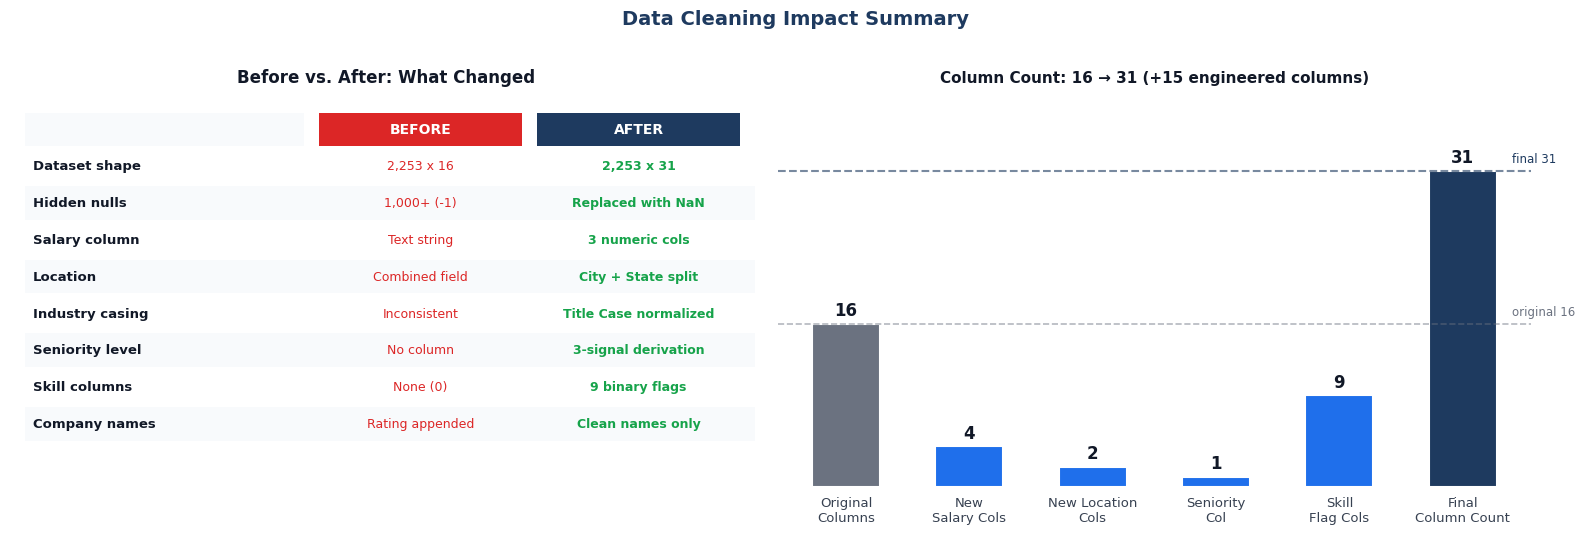

In [4]:
# @title
#before and after the cleaning of data
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
fig.patch.set_facecolor("#FFFFFF")

BLUE  = "#1F6FEB"; NAVY  = "#1E3A5F"; LT    = "#A8C8F0"
RED   = "#DC2626"; MUTED = "#6B7280"; TEXT  = "#111827"
GRN   = "#16A34A"; CARD  = "#F0F6FF"; BORD  = "#E5E7EB"

# LEFT: Before/After table
ax = axes[0]; ax.axis("off"); ax.set_facecolor("#FFFFFF")

rows = [
    ("Dataset shape",    "2,253 x 16",    "2,253 x 31"),
    ("Hidden nulls",     "1,000+ (-1)",   "Replaced with NaN"),
    ("Salary column",    "Text string",   "3 numeric cols"),
    ("Location",         "Combined field","City + State split"),
    ("Industry casing",  "Inconsistent",  "Title Case normalized"),
    ("Seniority level",  "No column",     "3-signal derivation"),
    ("Skill columns",    "None (0)",      "9 binary flags"),
    ("Company names",    "Rating appended","Clean names only"),
]
x0, x1, x2 = 0.02, 0.41, 0.70
w0, w1, w2  = 0.38, 0.28, 0.28
rh = 0.095; yt = 0.88

for j,(lbl,xp,wp,bg,fc) in enumerate(zip(
    ["", "BEFORE", "AFTER"],
    [x0,x1,x2],[w0,w1,w2],
    ["#F8FAFC", RED, NAVY],
    [TEXT,"white","white"])):
    ax.add_patch(Rectangle((xp,yt),wp-0.01,rh*0.9,facecolor=bg,edgecolor="none",
                            transform=ax.transAxes,zorder=2))
    ax.text(xp+(wp-0.01)/2,yt+rh*0.45,lbl,ha="center",va="center",
            fontsize=10,fontweight="bold",color=fc,transform=ax.transAxes,zorder=3)

for i,(metric,before,after) in enumerate(rows):
    y = yt-(i+1)*rh
    ax.add_patch(Rectangle((0.02,y),0.97,rh*0.92,
                            facecolor="#FFFFFF" if i%2==0 else "#F8FAFC",
                            edgecolor="none",transform=ax.transAxes,zorder=1))
    ax.text(x0+0.01,y+rh*0.45,metric,ha="left",va="center",
            fontsize=9.5,color=TEXT,fontweight="600",transform=ax.transAxes,zorder=3)
    ax.text(x1+(w1-0.01)/2,y+rh*0.45,before,ha="center",va="center",
            fontsize=9,color=RED,transform=ax.transAxes,zorder=3)
    ax.text(x2+(w2-0.01)/2,y+rh*0.45,after,ha="center",va="center",
            fontsize=9,color=GRN,fontweight="600",transform=ax.transAxes,zorder=3)

ax.set_title("Before vs. After: What Changed",fontsize=12,fontweight="bold",color=TEXT,pad=12)

# RIGHT: Column growth bar
ax2 = axes[1]; ax2.set_facecolor("white")
for s in ["top","right","left","bottom"]: ax2.spines[s].set_visible(False)
ax2.set_xticks([]); ax2.set_yticks([])

cat_labels = ["Original\nColumns","New\nSalary Cols","New Location\nCols",
              "Seniority\nCol","Skill\nFlag Cols","Final\nColumn Count"]
values     = [16, 4, 2, 1, 9, 31]
bar_colors = [MUTED, BLUE, BLUE, BLUE, BLUE, NAVY]

xb = np.arange(len(cat_labels))
bars2 = ax2.bar(xb,values,color=bar_colors,width=0.55,edgecolor="white",linewidth=1.5)
for bar,val in zip(bars2,values):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.4,str(val),
             ha="center",va="bottom",fontsize=12,fontweight="bold",color=TEXT)
ax2.set_xticks(xb)
ax2.set_xticklabels(cat_labels,fontsize=9.5,color="#374151")
ax2.tick_params(bottom=False)
ax2.set_ylim(0,38)
ax2.set_title("Column Count: 16 → 31 (+15 engineered columns)",
              fontsize=11,fontweight="bold",color=TEXT,pad=12)
ax2.axhline(16,color=MUTED,linewidth=1.2,linestyle="--",alpha=0.5)
ax2.text(5.4,16.5,"original 16",fontsize=8.5,color=MUTED,va="bottom")
ax2.axhline(31,color=NAVY,linewidth=1.5,linestyle="--",alpha=0.6)
ax2.text(5.4,31.5,"final 31",fontsize=8.5,color=NAVY,va="bottom")

plt.suptitle("Data Cleaning Impact Summary",
             fontsize=14,fontweight="black",color=NAVY,y=1.02)
plt.tight_layout()
plt.show()


In [14]:
# @title
# setup libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

df = pd.read_excel('glassdoor-cleaned.xlsx', index_col=0)

#cleaned the year founded column
df['founded'] = df['founded'].astype('Int64')

SKILL_COLS   = ['skill_python', 'skill_sql', 'skill_tableau', 'skill_excel',
                'skill_r', 'skill_power_bi', 'skill_spark',
                'skill_machine_learning', 'skill_statistics']
SKILL_LABELS = ['Python', 'SQL', 'Tableau', 'Excel',
                'R', 'Power BI', 'Spark', 'Machine Learning', 'Statistics']

print(f'Shape: {df.shape}')
display(df.head(3))

Shape: (2252, 28)


,salary_estimate,rating,company_name,location,headquarters,size,founded,type_of_ownership,industry,sector,...,skill_python,skill_sql,skill_tableau,skill_excel,skill_r,skill_power_bi,skill_spark,skill_machine_learning,skill_statistics,company_size_label
job_title,,,,,,,,,,,,,,,,,,,,,
"Data Analyst, Center on Immigration and Justice (CIJ)",$37K-$66K (Glassdoor est.),3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,...,1,1,0,0,1,0,0,0,1,3. Small-Mid (201-500)
Quality Data Analyst,$37K-$66K (Glassdoor est.),3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,...,0,1,0,1,1,0,0,0,1,7. Enterprise (10K+)
"Senior Data Analyst, Insights & Analytics Team [Customer Operations]",$37K-$66K (Glassdoor est.),3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,...,1,1,1,1,1,0,0,0,1,5. Large (1K-5K)


In [17]:
# @title
#final cleaned data
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">

  <div style="background: #1E3A5F; border-radius: 16px; padding: 24px 32px; margin-bottom: 18px;">
    <p style="color: #A8C8F0; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 6px 0;">Cleaned and Ready</p>
    <p style="color: white; font-size: 20px; font-weight: 800; margin: 0 0 6px 0;">
      Final Dataset: glassdoor-cleaned.xlsx
    </p>
    <p style="color: #A8C8F0; font-size: 13px; margin: 0;">
      All subsequent visualizations and insights are generated from this single, clean, version-controlled source.
    </p>
  </div>

  <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px; margin-bottom: 18px;">
    <div style="background: #F0F6FF; border-radius: 12px; padding: 16px; text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #1F6FEB; font-size: 24px; font-weight: 800; margin: 0;">2,253</p>
      <p style="color: #6B7280; font-size: 12px; margin: 0;">Job Postings</p>
    </div>
    <div style="background: #F0F6FF; border-radius: 12px; padding: 16px; text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #1F6FEB; font-size: 24px; font-weight: 800; margin: 0;">31</p>
      <p style="color: #6B7280; font-size: 12px; margin: 0;">Columns (was 16)</p>
    </div>
    <div style="background: #F0F6FF; border-radius: 12px; padding: 16px; text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #1F6FEB; font-size: 24px; font-weight: 800; margin: 0;">9</p>
      <p style="color: #6B7280; font-size: 12px; margin: 0;">Skill Flag Columns</p>
    </div>
    <div style="background: #F0F6FF; border-radius: 12px; padding: 16px; text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #1F6FEB; font-size: 24px; font-weight: 800; margin: 0;">$72.1K</p>
      <p style="color: #6B7280; font-size: 12px; margin: 0;">Avg Salary ($33.5K–$150K)</p>
    </div>
  </div>

  <div style="background: white; border-radius: 14px; padding: 20px 28px;
              border: 1px solid #E5E7EB; margin-bottom: 16px;">
    <p style="color: #1F6FEB; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 14px 0;">Key Columns Available for Analysis</p>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; font-size: 13px; color: #374151;">
      <div>
        <p style="font-weight: 700; color: #111827; margin: 0 0 6px 0;">Original (retained)</p>
        <ul style="margin: 0; padding-left: 18px; line-height: 1.8;">
          <li><code>job_title</code> — full posting title</li>
          <li><code>company_name</code> — cleaned employer name</li>
          <li><code>industry</code> / <code>sector</code> — normalized casing</li>
          <li><code>rating</code> — Glassdoor score (NaN where unknown)</li>
        </ul>
      </div>
      <div>
        <p style="font-weight: 700; color: #111827; margin: 0 0 6px 0;">Engineered (new)</p>
        <ul style="margin: 0; padding-left: 18px; line-height: 1.8;">
          <li><code>city</code> / <code>state</code> — split from location</li>
          <li><code>salary_min</code> / <code>salary_max</code> / <code>salary_avg</code></li>
          <li><code>seniority_level</code> — Entry / Mid / Senior</li>
          <li><code>skill_sql</code>, <code>skill_python</code>, <code>skill_tableau</code> + 6 more</li>
        </ul>
      </div>
    </div>
  </div>

  <div style="background: #1E3A5F; border-radius: 14px; padding: 20px 28px;">
    <p style="color: #A8C8F0; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 6px 0;">Up Next</p>
    <p style="color: white; font-size: 15px; font-weight: 600; margin: 0; line-height: 1.6;">
      With 2,253 clean, structured job postings in hand, we now move to the core analysis.
      Three research questions. One dataset.
      <strong style="color: #A8C8F0;">Let the data speak.</strong>
    </p>
  </div>

</div>
"""))


---
# 🔍 **From Reddit Advice to Data Insights**

> *The dataset is clean. The questions are defined. Now we answer them.*

With 2,253 structured job postings in hand, we move through each research question in order: industry first, then geography, then skills. Each section closes with a **direct, actionable insight** for job seekers.


---
# 🏭 **Where Are the Jobs?**

## **RQ1 — Industry Demand: Where Are Data Analysts Most Needed?**

> **Which industries and sectors demonstrate the highest hiring activity for Data Analysts?**

**What we measure:**
- **Total Job Postings per Industry** — raw hiring volume
- **Industry Share of Total Job Market** — each industry's slice of all postings
- **Sector-level view** — zoomed-out groupings of related industries

**Why it matters:** Applying broadly means competing in oversaturated niches. Knowing which industries actively hire Data Analysts helps you focus where opportunities are.

In [18]:
# @title
#theme and colors
BG        = '#FFFFFF'
CARD      = '#F8FAFC'
BLUE      = '#1F6FEB'
ENTRY     = '#A8C8F0'
MID       = '#1F6FEB'
SENIOR    = '#1E3A5F'
MUTED     = '#6B7280'
BORDER    = '#E5E7EB'
BLACK     = '#111827'
WHITE     = '#FFFFFF'

LEVEL_COLORS = {
    'Entry-Level': '#A8C8F0',
    'Mid-Level':   '#1F6FEB',
    'Senior':      '#1E3A5F'
}

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.facecolor':     WHITE,
    'figure.facecolor':   WHITE,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.color':         BORDER,
    'grid.linewidth':     0.6,
    'axes.labelcolor':    MUTED,
    'xtick.color':        MUTED,
    'ytick.color':        BLACK,
    'text.color':         BLACK,
    'font.weight':        'bold',
})

In [19]:
# @title
# summary
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">
  <div style="display: flex; gap: 16px;">

    <div style="flex: 1; background: #F0F6FF; border-radius: 16px; padding: 20px;
                text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #6B7280; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
                text-transform: uppercase; margin: 0 0 8px 0;">Total Postings</p>
      <p style="color: #1F6FEB; font-size: 28px; font-weight: 800; margin: 0;">2,253</p>
    </div>

    <div style="flex: 1; background: #F0F6FF; border-radius: 16px; padding: 20px;
                text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #6B7280; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
                text-transform: uppercase; margin: 0 0 8px 0;">Top Industry</p>
      <p style="color: #1E3A5F; font-size: 20px; font-weight: 800; margin: 0;">IT Services</p>
    </div>

    <div style="flex: 1; background: #F0F6FF; border-radius: 16px; padding: 20px;
                text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #6B7280; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
                text-transform: uppercase; margin: 0 0 8px 0;">Top Sector</p>
      <p style="color: #1E3A5F; font-size: 20px; font-weight: 800; margin: 0;">Information Technology</p>
    </div>

    <div style="flex: 1; background: #F0F6FF; border-radius: 16px; padding: 20px;
                text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #6B7280; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
                text-transform: uppercase; margin: 0 0 8px 0;">Industries Covered</p>
      <p style="color: #1F6FEB; font-size: 28px; font-weight: 800; margin: 0;">88</p>
    </div>

    <div style="flex: 1; background: #F0F6FF; border-radius: 16px; padding: 20px;
                text-align: center; border: 1px solid #A8C8F0;">
      <p style="color: #6B7280; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
                text-transform: uppercase; margin: 0 0 8px 0;">Sectors Covered</p>
      <p style="color: #1F6FEB; font-size: 28px; font-weight: 800; margin: 0;">24</p>
    </div>

  </div>
</div>
"""))

## 📊 **Industry Hiring Volume & Average Salary**

> Each bar is labeled with its **raw count and percentage share** of the market, so you can see both absolute volume and relative weight at a glance. Bars highlighted in **dark navy** are the top performers in each dimension.

`Bar Charts`


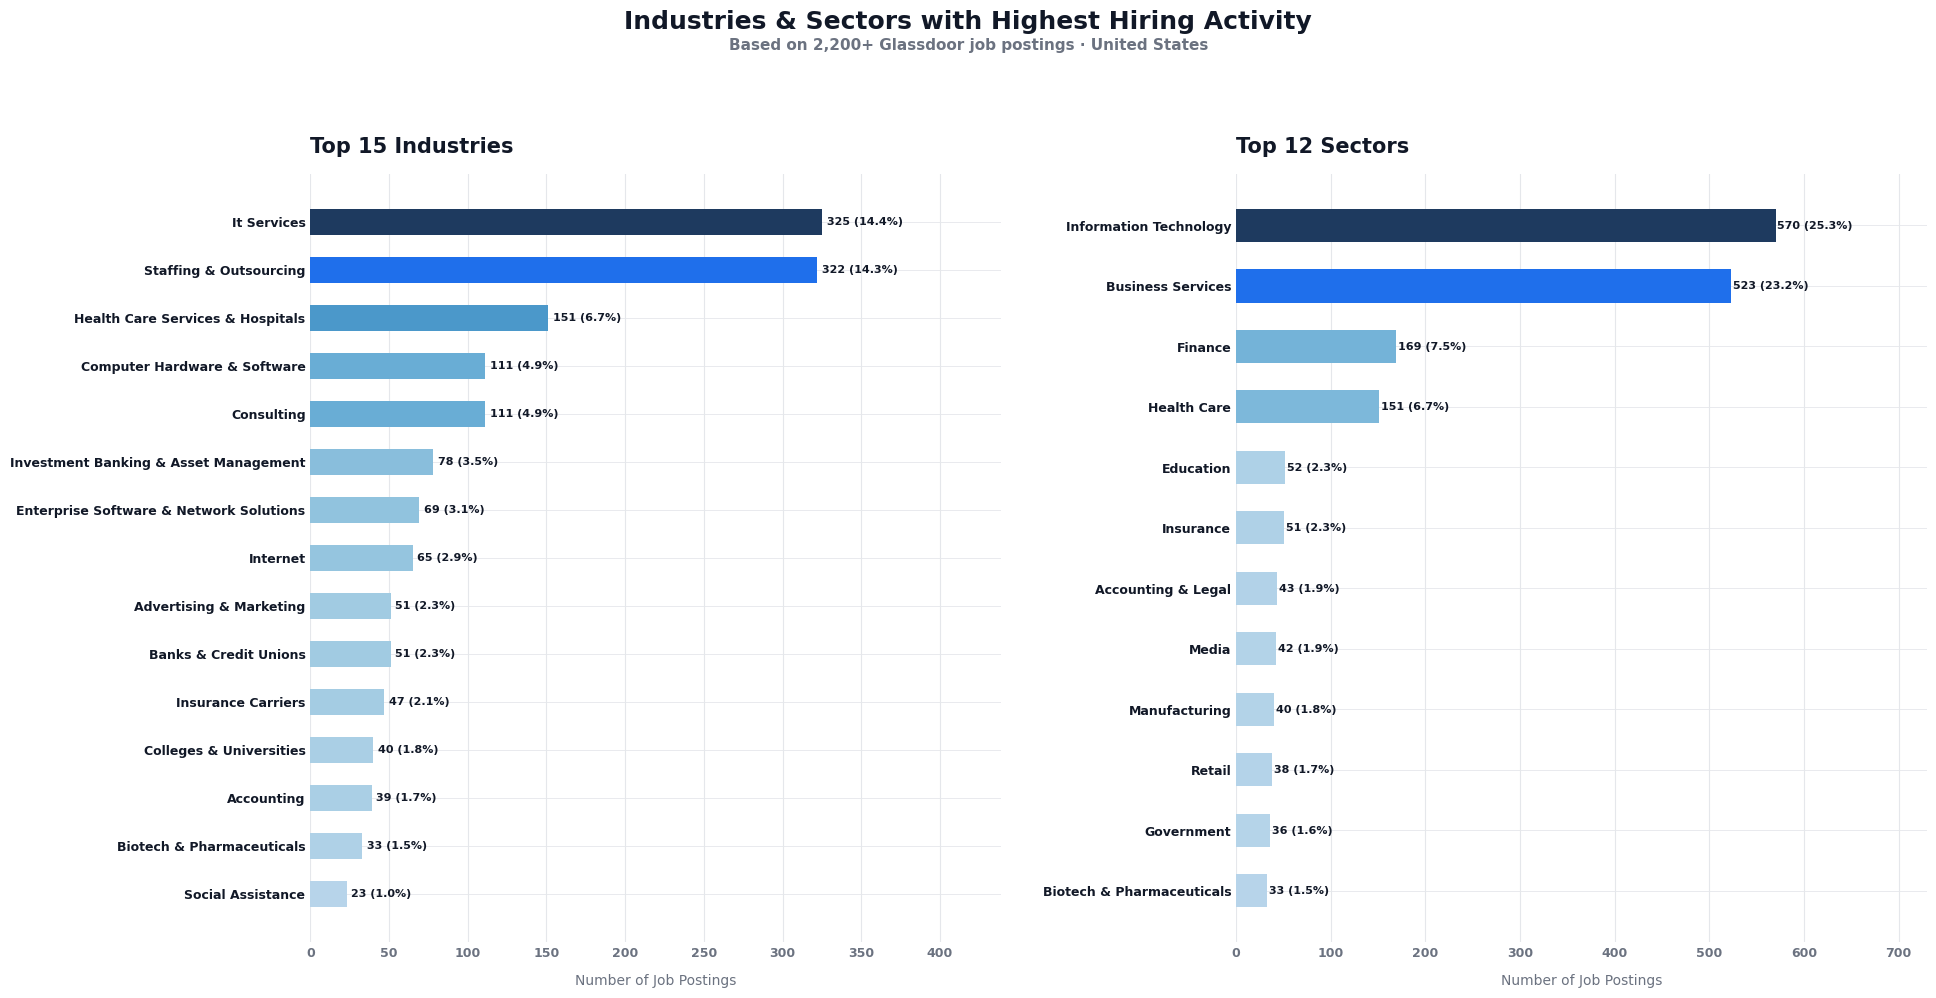

In [22]:
# @title
# rq1 charts
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor(WHITE)

for ax in axes:
    ax.set_facecolor(WHITE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(axis='x', color=BORDER, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

total   = len(df)
top_ind = df['industry'].value_counts().dropna().head(15).sort_values()
norm    = plt.Normalize(top_ind.values.min(), top_ind.values.max())
colors_ind = [plt.cm.Blues(0.3 + 0.7 * norm(v)) for v in top_ind.values]

# Highlight top 2
colors_ind[-1] = '#1E3A5F'  # #1 bar — darkest navy
colors_ind[-2] = '#1F6FEB'  # #2 bar — medium blue

bars = axes[0].barh(top_ind.index, top_ind.values,
                    color=colors_ind, edgecolor='none', height=0.55)
for bar, val in zip(bars, top_ind.values):
    pct = val / total * 100
    axes[0].text(val + 3, bar.get_y() + bar.get_height()/2,
                 f'{val} ({pct:.1f}%)', va='center', fontsize=8,
                 color=BLACK, fontweight='bold')

axes[0].set_title('Top 15 Industries', fontsize=15, fontweight='bold',
                  color=BLACK, pad=15, loc='left')
axes[0].set_xlabel('Number of Job Postings', fontsize=10, color=MUTED, labelpad=10)
axes[0].set_xlim(0, top_ind.max() * 1.35)
axes[0].tick_params(axis='y', labelsize=9, labelcolor=BLACK, length=0)
axes[0].tick_params(axis='x', labelsize=9, labelcolor=MUTED, length=0)
for label in axes[0].get_yticklabels():
    label.set_fontweight('bold')

top_sec = df['sector'].value_counts().dropna().head(12).sort_values()
norm2   = plt.Normalize(top_sec.values.min(), top_sec.values.max())
colors_sec = [plt.cm.Blues(0.3 + 0.7 * norm2(v)) for v in top_sec.values]

# Highlight top 2
colors_sec[-1] = '#1E3A5F'  # #1 bar — darkest navy
colors_sec[-2] = '#1F6FEB'  # #2 bar — medium blue

bars2 = axes[1].barh(top_sec.index, top_sec.values,
                     color=colors_sec, edgecolor='none', height=0.55)
for bar, val in zip(bars2, top_sec.values):
    pct = val / total * 100
    axes[1].text(val + 2, bar.get_y() + bar.get_height()/2,
                 f'{val} ({pct:.1f}%)', va='center', fontsize=8,
                 color=BLACK, fontweight='bold')

axes[1].set_title('Top 12 Sectors', fontsize=15, fontweight='bold',
                  color=BLACK, pad=15, loc='left')
axes[1].set_xlabel('Number of Job Postings', fontsize=10, color=MUTED, labelpad=10)
axes[1].set_xlim(0, top_sec.max() * 1.28)
axes[1].tick_params(axis='y', labelsize=9, labelcolor=BLACK, length=0)
axes[1].tick_params(axis='x', labelsize=9, labelcolor=MUTED, length=0)
for label in axes[1].get_yticklabels():
    label.set_fontweight('bold')

fig.suptitle('Industries & Sectors with Highest Hiring Activity',
             fontsize=18, fontweight='bold', color=BLACK, y=1.02)
fig.text(0.5, 0.98, 'Based on 2,200+ Glassdoor job postings · United States',
         ha='center', fontsize=11, color=MUTED)

plt.tight_layout(pad=3)
plt.savefig('rq1_overall.png', dpi=150, bbox_inches='tight',
            facecolor=WHITE, pad_inches=0.4)
plt.show()

## 🎓 **Top Industries by Seniority Level**

> Breaks down industry demand by career stage: **Entry-Level**, **Mid-Level**, and **Senior**, so you can see which industries are actually open to you *right now* based on your experience. The same industry can rank very differently depending on the level you are applying for.

`Bar Charts`


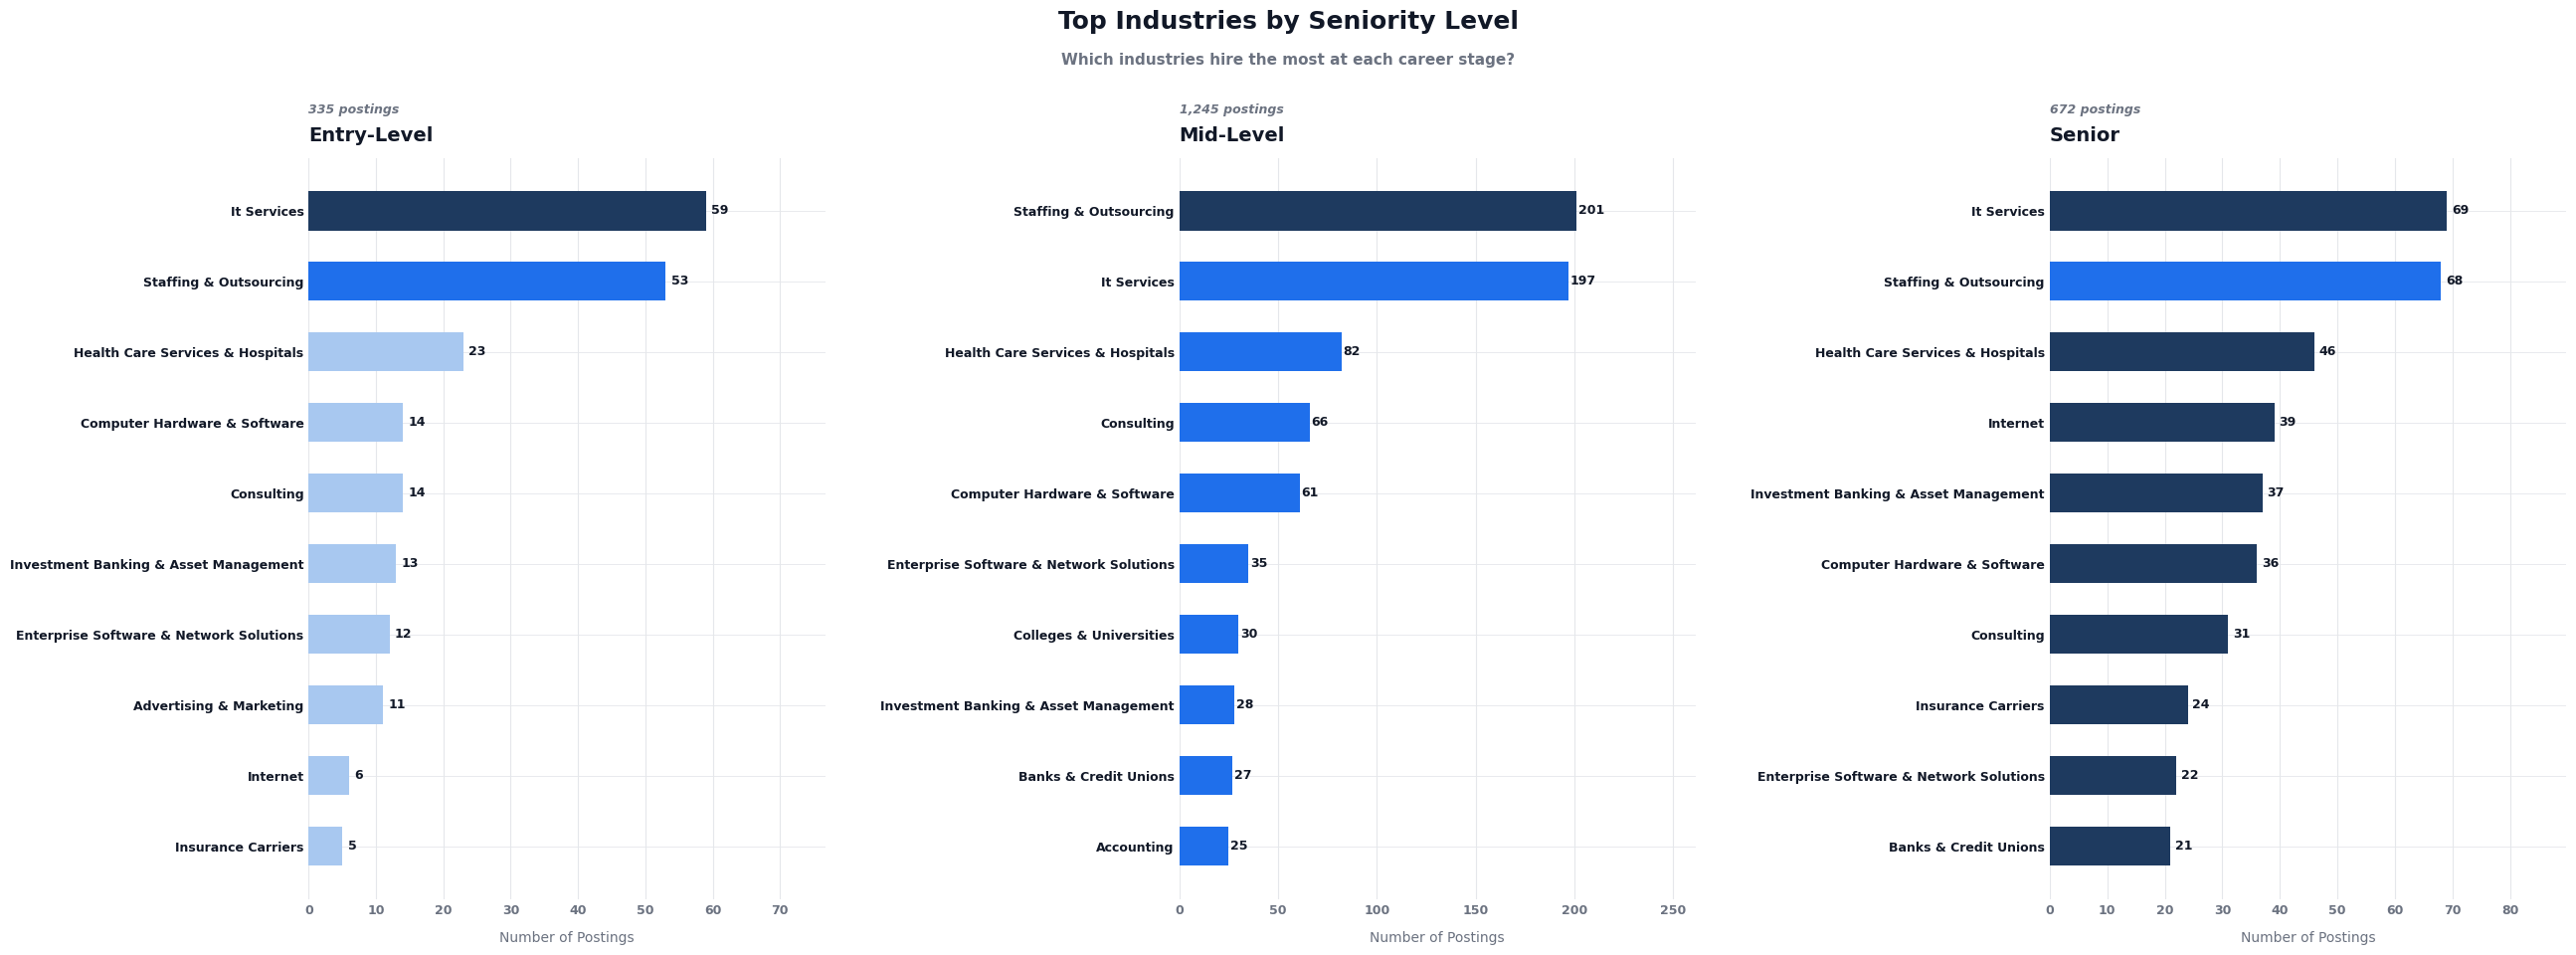

In [23]:
# @title
# charts
fig, axes = plt.subplots(1, 3, figsize=(26, 9))
fig.patch.set_facecolor(WHITE)

levels = ['Entry-Level', 'Mid-Level', 'Senior']
colors = [ENTRY, MID, SENIOR]

for i, (level, color) in enumerate(zip(levels, colors)):
    level_df = df[df['seniority_level'] == level]
    top_ind  = level_df['industry'].value_counts().dropna().head(10).sort_values()

    ax = axes[i]
    ax.set_facecolor(WHITE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(axis='x', color=BORDER, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    # Base colors
    bar_colors = [color] * len(top_ind)
    bar_colors[-1] = '#1E3A5F'  # #1 bar
    bar_colors[-2] = '#1F6FEB'  # #2 bar

    bars = ax.barh(top_ind.index, top_ind.values,
                   color=bar_colors, edgecolor='none', height=0.55)
    for bar, val in zip(bars, top_ind.values):
        ax.text(val + 0.8, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9,
                color=BLACK, fontweight='bold')

    ax.set_title(f'{level}', fontsize=14, fontweight='bold',
                 color=BLACK, pad=12, loc='left')
    ax.set_xlabel('Number of Postings', fontsize=10, color=MUTED, labelpad=10)
    ax.text(0, 1.06, f'{len(level_df):,} postings', transform=ax.transAxes,
            fontsize=9, color=MUTED, fontstyle='italic')
    ax.set_xlim(0, top_ind.max() * 1.3)
    ax.tick_params(axis='y', labelsize=9, labelcolor=BLACK, length=0)
    ax.tick_params(axis='x', labelsize=9, labelcolor=MUTED, length=0)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

fig.text(0.5, 1.04, 'Top Industries by Seniority Level',
         ha='center', fontsize=18, fontweight='bold', color=BLACK)
fig.text(0.5, 1.00, 'Which industries hire the most at each career stage?',
         ha='center', fontsize=11, color=MUTED)

plt.tight_layout(rect=[0, 0, 1, 0.97], w_pad=4)
plt.savefig('rq1_industry_seniority.png', dpi=150, bbox_inches='tight',
            facecolor=WHITE, pad_inches=0.4)
plt.show()

## 🏢 **Top Sectors by Seniority Level**

>A zoomed-out version of the industry view, grouping roles into broader **economic sectors**. Useful for spotting macro-level patterns, for example, whether Information Technology dominates across all levels or whether Finance opens up more at Senior stage.

`Bar Charts`


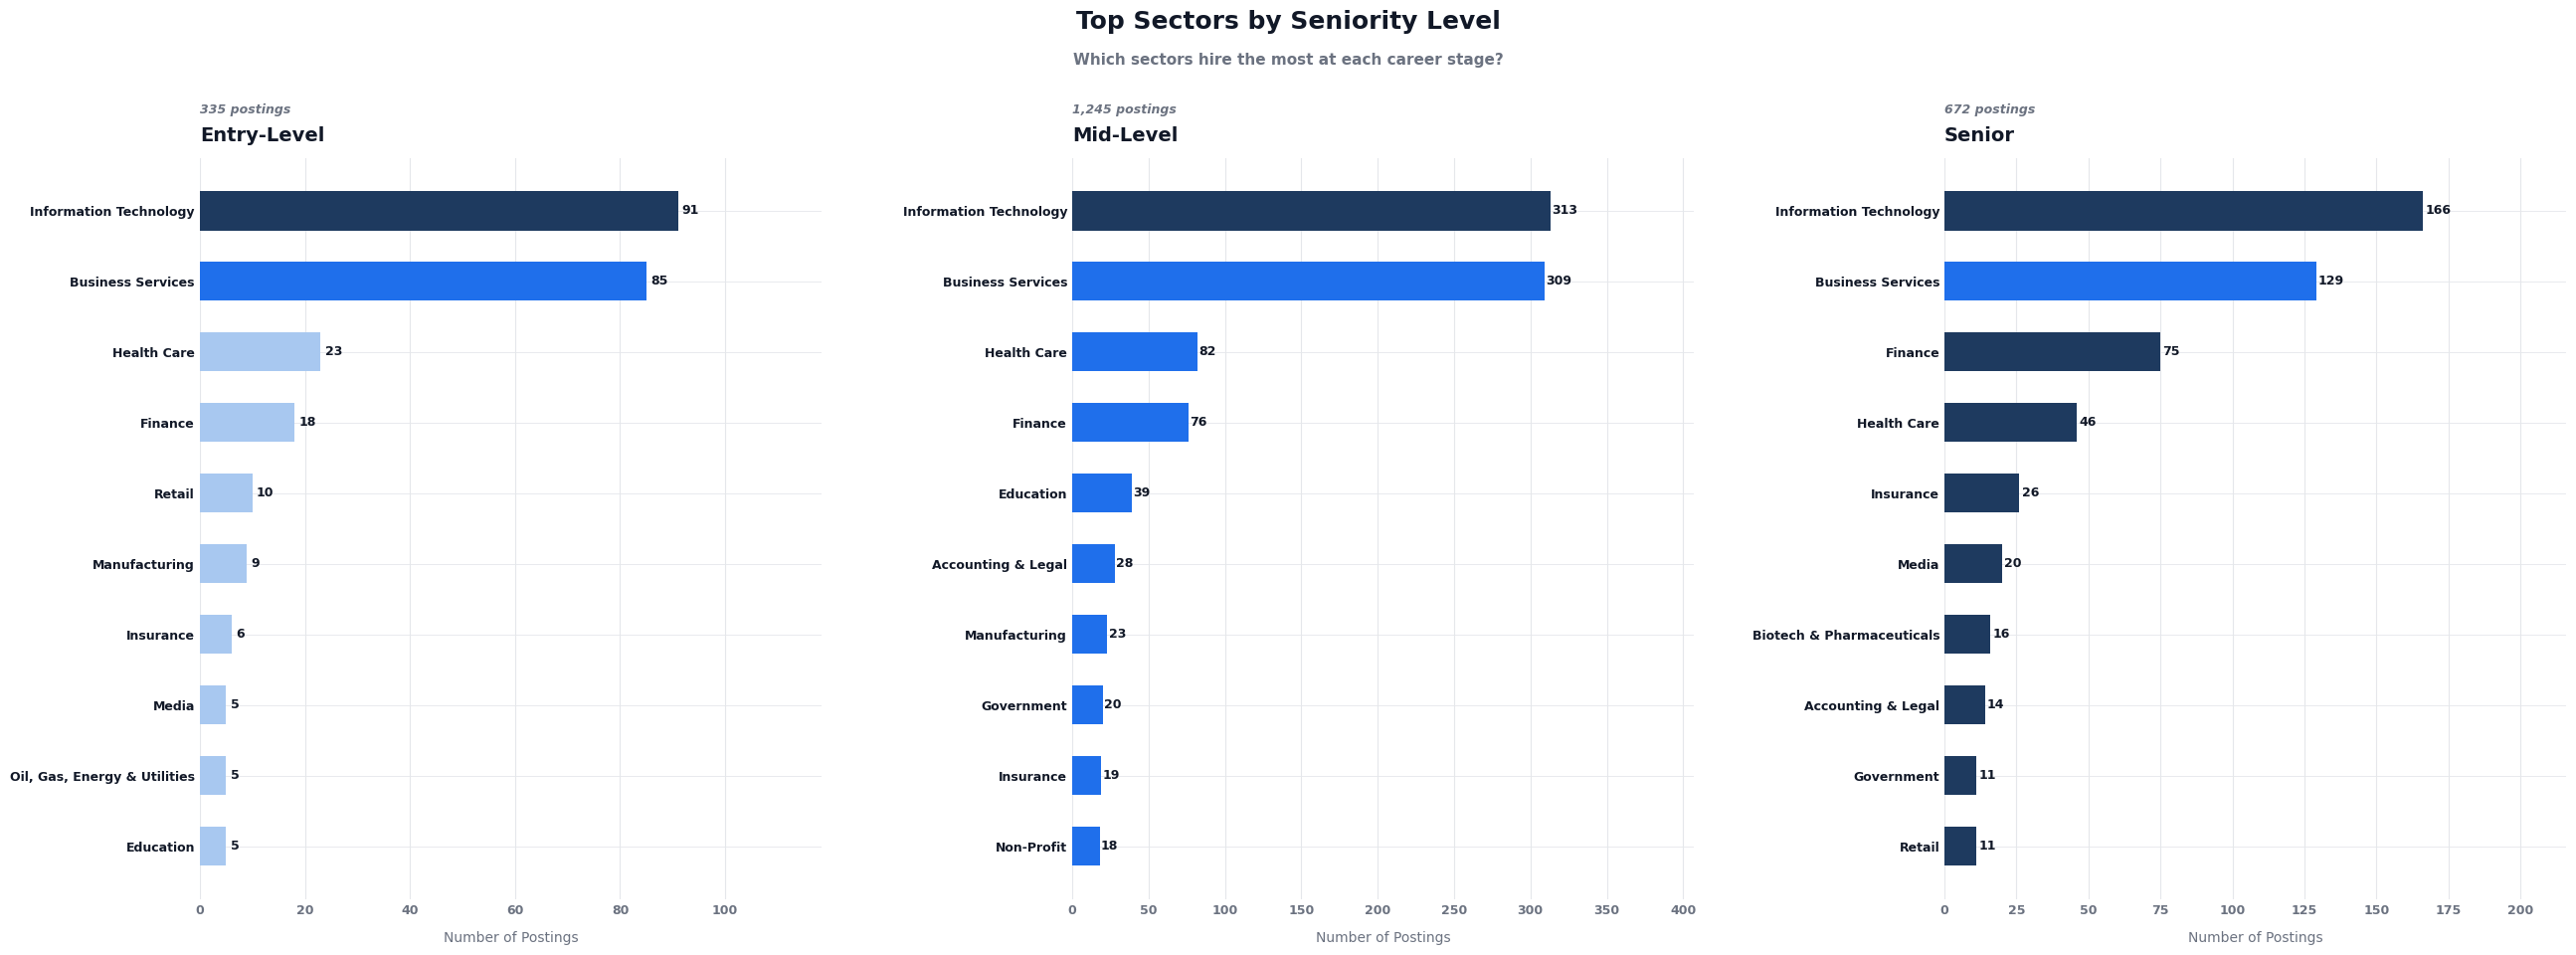

In [24]:
# @title
fig, axes = plt.subplots(1, 3, figsize=(26, 9))
fig.patch.set_facecolor(WHITE)

levels = ['Entry-Level', 'Mid-Level', 'Senior']
colors = [ENTRY, MID, SENIOR]

for i, (level, color) in enumerate(zip(levels, colors)):
    level_df = df[df['seniority_level'] == level]
    top_sec  = level_df['sector'].value_counts().dropna().head(10).sort_values()

    ax = axes[i]
    ax.set_facecolor(WHITE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(axis='x', color=BORDER, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    # Base colors
    bar_colors = [color] * len(top_sec)
    bar_colors[-1] = '#1E3A5F'  # #1 bar
    bar_colors[-2] = '#1F6FEB'  # #2 bar

    bars = ax.barh(top_sec.index, top_sec.values,
                   color=bar_colors, edgecolor='none', height=0.55)
    for bar, val in zip(bars, top_sec.values):
        ax.text(val + 0.8, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9,
                color=BLACK, fontweight='bold')

    ax.set_title(f'{level}', fontsize=14, fontweight='bold',
                 color=BLACK, pad=12, loc='left')
    ax.set_xlabel('Number of Postings', fontsize=10, color=MUTED, labelpad=10)
    ax.text(0, 1.06, f'{len(level_df):,} postings', transform=ax.transAxes,
            fontsize=9, color=MUTED, fontstyle='italic')
    ax.set_xlim(0, top_sec.max() * 1.3)
    ax.tick_params(axis='y', labelsize=9, labelcolor=BLACK, length=0)
    ax.tick_params(axis='x', labelsize=9, labelcolor=MUTED, length=0)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

fig.text(0.5, 1.04, 'Top Sectors by Seniority Level',
         ha='center', fontsize=18, fontweight='bold', color=BLACK)
fig.text(0.5, 1.00, 'Which sectors hire the most at each career stage?',
         ha='center', fontsize=11, color=MUTED)

plt.tight_layout(rect=[0, 0, 1, 0.97], w_pad=4)
plt.savefig('rq1_sector_seniority.png', dpi=150, bbox_inches='tight',
            facecolor=WHITE, pad_inches=0.4)
plt.show()


In [27]:
# @title
# key takeaways
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">
  <div style="background: #F0F6FF; border-radius: 16px; padding: 24px 35px; border: 1px solid #A8C8F0;">

    <p style="color: #1F6FEB; font-size: 13px; font-weight: 700; letter-spacing: 1.5px;
              margin: 0 0 16px 0;">📌 KEY TAKEAWAYS — Industry Demand</p>

    <div style="display: flex; align-items: flex-start; margin-bottom: 16px;">
      <div style="background: #1F6FEB; color: white; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">1</div>
      <p style="color: #111827; font-size: 14px; line-height: 1.7; margin: 0;">
        <strong>IT Services (17.1%) and Staffing &amp; Outsourcing (17.0%) together control 34% of the market.</strong>
        Add Health Care (7.9%), Computer Hardware (5.8%), and Consulting (5.8%) and the
        top 5 industries account for <strong style="color:#1F6FEB;">53.7% of all postings</strong>.
        The market is far more concentrated than it appears.
      </p>
    </div>

    <div style="display: flex; align-items: flex-start; margin-bottom: 16px;">
      <div style="background: #1E3A5F; color: white; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">2</div>
      <p style="color: #111827; font-size: 14px; line-height: 1.7; margin: 0;">
        <strong>High-pay industries hire far less frequently.</strong>
        Biotech &amp; Pharma pays the most at
        <strong style="color:#1F6FEB;">$83.1K avg</strong> — but posts only 33 jobs (1.7% of the market).
        Internet roles average <strong style="color:#1F6FEB;">$79.7K</strong> but just 65 postings.
        Compare that to IT Services: <strong>$71.3K across 325 postings</strong>.
        Biotech pays 16% more but has 10x fewer openings.
      </p>
    </div>

    <div style="display: flex; align-items: flex-start;">
      <div style="background: #A8C8F0; color: #1E3A5F; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">💡</div>
      <p style="color: #374151; font-size: 13px; line-height: 1.7; margin: 0; font-style: italic;">
        <strong>The strategy:</strong> Start in IT Services, Staffing, or Health Care for your first role —
        highest volume means the most shots on goal. After 2–3 years, pivot to Internet or Biotech
        where pay is 12–16% higher but selectivity is much steeper.
      </p>
    </div>

  </div>
</div>
"""))


In [29]:
# @title
# transition
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">
  <div style="background: #1E3A5F; border-radius: 16px; padding: 24px 35px;">
    <p style="color: #A8C8F0; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 8px 0;">Up Next</p>
    <p style="color: #FFFFFF; font-size: 16px; font-weight: 600; margin: 0; line-height: 1.6;">
      Now that we know <strong style="color:#A8C8F0;">which industries</strong> to target,
      the next question is <strong style="color:#A8C8F0;">where in the U.S.</strong> should
      you be looking? RQ2 covers the best states for job demand and salary.
    </p>
  </div>
</div>
"""))

# **🗺️ Geographic Opportunity: Where Are the Best Locations for Data Analysts?**
## **RQ2 — Geographic Opportunity: Which U.S. States Are Best for Data Analysts?**

> **Which U.S. states provide the most favorable opportunities for Data Analysts by offering the strongest combination of job demand and competitive compensation?**

**What we measure:**
- **Total Job Postings per State** — raw hiring volume across the U.S.
- **Average Salary by State** — where compensation stands out
- **Combined View: Demand vs. Pay** — identifying states that win on both dimensions

**Why it matters:** Location is a multiplier. Where you aim changes the math entirely. Knowing which states offer both volume and strong pay helps you target markets where opportunity and compensation align.

In [32]:
# @title
# Install and Import Libraries
!pip install plotly geopandas --quiet

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Design constants
BG   = '#F7F9FC'
FONT = 'Inter, Arial, sans-serif'

#Compute State Metrics
VALID_STATES = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN',
    'IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV',
    'NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN',
    'TX','UT','VT','VA','WA','WV','WI','WY','DC'
]

# State-level aggregation
state_df = (
    df.groupby('state')
      .agg(job_count=('salary_avg', 'count'),
           avg_salary=('salary_avg', 'mean'))
      .reset_index()
)
state_df = state_df[
    state_df['state'].isin(VALID_STATES)
].copy()

# Sort by job count for most charts
state_df = state_df.sort_values('job_count', ascending=False).reset_index(drop=True)

# Formatted display columns
state_df['avg_salary_fmt']   = state_df['avg_salary'].apply(lambda x: f'${x/1000:.1f}K')

print(f'   States with sufficient data: {len(state_df)}')
state_df[['state','job_count','avg_salary_fmt']]

   States with sufficient data: 19


,state,job_count,avg_salary_fmt
0,CA,626,$88.4K
1,TX,394,$58.8K
2,NY,345,$71.4K
3,IL,164,$78.3K
4,PA,114,$61.7K
5,AZ,97,$70.8K
6,NC,90,$68.1K
7,CO,88,$73.6K
8,NJ,86,$73.0K
9,WA,53,$64.8K


## **🧭 Job Postings by State**

> **Where are the jobs?** An interactive choropleth map showing the **total number of Data Analyst postings per U.S. state**. Darker shading means more jobs. Hover over any state to see exact counts and a breakdown of top industries hiring there.

```Chloropleth Map ```

In [34]:
# @title
#job postings by state
state_df['hover_jobs'] = (
    '<b>' + state_df['state'] + '</b><br>' +
    '─────────────────<br>' +
    '💼 Job Postings: <b>' + state_df['job_count'].astype(str) + '</b><br>' +
    '💰 Avg Salary: '      + state_df['avg_salary_fmt'] + '<br>'
)

fig_jobs_map = px.choropleth(
    state_df,
    locations        = 'state',
    locationmode     = 'USA-states',
    color            = 'job_count',
    custom_data      = ['hover_jobs'],
    color_continuous_scale = [
        [0.0,  '#EFF6FF'],
        [0.25, '#BFDBFE'],
        [0.5,  '#60A5FA'],
        [0.75, '#2563EB'],
        [1.0,  '#1E3A8A'],
    ],
    scope            = 'usa',
    labels           = {'job_count': 'Job Postings'},
)

fig_jobs_map.update_traces(
    hovertemplate     = '%{customdata[0]}<extra></extra>',
    marker_line_color = 'white',
    marker_line_width = 0.8,
)

fig_jobs_map.update_layout(
    title = dict(
        text = '<b>Data Analyst Job Postings by State</b><br>'
               '<sup>Darker blue = more job opportunities  |  Hover over any state for details</sup>',
        x=0.5, xanchor='center',
        font=dict(size=20, family=FONT, color='#111827')
    ),
    geo = dict(
        showlakes=True, lakecolor='#DBEAFE',
        bgcolor=BG, landcolor='#F3F4F6',
        showcoastlines=False,
    ),
    coloraxis_colorbar = dict(
        title     = 'Job Count',
        len       = 0.7,
        thickness = 16,
        outlinewidth = 0,
    ),
    paper_bgcolor = BG,
    font          = dict(family=FONT),
    margin        = dict(l=0, r=0, t=80, b=20),
    height        = 500,
)

fig_jobs_map.show()

## 🗺️ **Average Salary by State**

> **Where does the pay stand out?** The same map, now colored by **average salary**. Compare this directly with the job volume map above, high salary doesn't always mean high demand. States that look similar on one map can look completely different on the other, which is exactly why we need both views.

`Choropleth Map`





In [36]:
# @title
# ave salery by state
state_df['hover_sal'] = (
    '<b>' + state_df['state'] + '</b><br>' +
    '─────────────────<br>' +
    '💰 Avg Salary: <b>'   + state_df['avg_salary_fmt'] + '</b><br>' +
    '💼 Job Postings: '    + state_df['job_count'].astype(str)
)

fig_sal_map = px.choropleth(
    state_df,
    locations        = 'state',
    locationmode     = 'USA-states',
    color            = 'avg_salary',
    custom_data      = ['hover_sal'],
    color_continuous_scale = [
        [0.0,  '#F0FDF4'],
        [0.25, '#BBF7D0'],
        [0.5,  '#4ADE80'],
        [0.75, '#16A34A'],
        [1.0,  '#14532D'],
    ],
    scope            = 'usa',
    labels           = {'avg_salary': 'Avg Salary'},
)

fig_sal_map.update_traces(
    hovertemplate     = '%{customdata[0]}<extra></extra>',
    marker_line_color = 'white',
    marker_line_width = 0.8,
)

fig_sal_map.update_layout(
    title = dict(
        text = '<b>Average Data Analyst Salary by State</b><br>'
               '<sup>Darker green = higher pay  |  Hover over any state for details</sup>',
        x=0.5, xanchor='center',
        font=dict(size=20, family=FONT, color='#111827')
    ),
    geo = dict(
        showlakes=True, lakecolor='#DCFCE7',
        bgcolor=BG, landcolor='#F3F4F6',
        showcoastlines=False,
    ),
    coloraxis_colorbar = dict(
        title        = 'Avg Salary',
        tickprefix   = '$',
        tickformat   = ',.0f',
        len          = 0.7,
        thickness    = 16,
        outlinewidth = 0,
    ),
    paper_bgcolor = BG,
    font          = dict(family=FONT),
    margin        = dict(l=0, r=0, t=80, b=20),
    height        = 500,
)

fig_sal_map.show()

## 📊 **Jobs vs. Salary per State**

> Each dot is a state. **X-axis** = average salary. **Y-axis** = job count. **Bubble size** = job count.
> States in the **top-right** have both high demand AND high pay, **the best of both worlds.**

>Reference lines mark the **median salary** and **median job count** so you can instantly see which quadrant each state falls into.


```Scatter Plot ```

In [38]:
# @title
#job vs salary per state
fig_scatter = px.scatter(
    state_df,
    x            = 'avg_salary',
    y            = 'job_count',
    size         = 'job_count',
    text         = 'state',
    hover_name   = 'state',
    hover_data   = {
        'avg_salary'   : ':$,.0f',
        'job_count'    : True,
    },
    color        = 'avg_salary',
    color_continuous_scale = 'Blues',
    size_max     = 80,
    labels = {
        'avg_salary'   : 'Average Salary (USD)',
        'job_count'    : 'Number of Job Postings',
    },
)

fig_scatter.update_traces(
    textposition      = 'top center',
    textfont          = dict(size=11, color='#1F2937', family=FONT),
    marker_line_color = 'white',
    marker_line_width = 1.5,
)

# Median reference lines
med_sal = state_df['avg_salary'].median()
med_job = state_df['job_count'].median()

fig_scatter.add_vline(
    x=med_sal, line_dash='dot', line_color='#9CA3AF', line_width=1.5,
    annotation_text=f'Median salary ${med_sal/1000:.0f}K',
    annotation_position='bottom right',
    annotation_font=dict(size=10, color='#9CA3AF')
)
fig_scatter.add_hline(
    y=med_job, line_dash='dot', line_color='#9CA3AF', line_width=1.5,
    annotation_text=f'Median {int(med_job)} jobs',
    annotation_position='top left',
    annotation_font=dict(size=10, color='#9CA3AF')
)

# Quadrant labels
x_max = state_df['avg_salary'].max()
y_max = state_df['job_count'].max()

fig_scatter.add_annotation(
    x=x_max, y=y_max,
    text='🏆 High pay + High demand',
    showarrow=False, xanchor='right',
    font=dict(size=11, color='#1D4ED8', family=FONT)
)
fig_scatter.add_annotation(
    x=state_df['avg_salary'].min(), y=y_max,
    text='📦 High demand, lower pay',
    showarrow=False, xanchor='left',
    font=dict(size=11, color='#6B7280', family=FONT)
)

fig_scatter.update_layout(
    title = dict(
        text = '<b>Job Postings vs. Average Salary — by State</b><br>'
               '<sup>Bubble size = job count  |  Hover for salary details  |  Top-right = best of both</sup>',
        x=0.5, xanchor='center',
        font=dict(size=18, family=FONT, color='#111827')
    ),
    xaxis = dict(
        tickprefix='$', tickformat=',.0f',
        gridcolor='#E5E7EB', zeroline=False,
        title_font=dict(size=13)
    ),
    yaxis = dict(
        gridcolor='#E5E7EB', zeroline=False,
        title_font=dict(size=13)
    ),
    coloraxis_showscale = False,
    paper_bgcolor = BG,
    plot_bgcolor  = BG,
    font          = dict(family=FONT),
    height        = 580,
    margin        = dict(l=60, r=60, t=90, b=60),
)

fig_scatter.show()

## 💻 **Jobs and Salary Together**

> A combined view comparing **job count** and **average salary** for the top 10 states side by side. Makes it easy to spot states that rank high on both dimensions.

```Side-by-side Dashboard ```


In [40]:
# @title
top10 = state_df.head(10).copy()

fig_dash = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        '💼 Job Postings (Top 10 States by Demand)',
        '💰 Average Salary (same top 10 states)',
    ),
    horizontal_spacing=0.12,
)

# Left: Job count
jobs_sorted = top10.sort_values('job_count')
fig_dash.add_trace(
    go.Bar(
        x            = jobs_sorted['job_count'],
        y            = jobs_sorted['state'],
        orientation  = 'h',
        marker       = dict(
            color      = jobs_sorted['job_count'],
            colorscale = 'Blues',
            line       = dict(color='white', width=0.6),
        ),
        text         = jobs_sorted['job_count'],
        textposition = 'outside',
        textfont     = dict(size=10),
        showlegend   = False,
        hovertemplate = '<b>%{y}</b><br>Jobs: %{x}<extra></extra>',
    ),
    row=1, col=1
)

# Right: Average salary (same order as left)
fig_dash.add_trace(
    go.Bar(
        x            = jobs_sorted['avg_salary'],
        y            = jobs_sorted['state'],
        orientation  = 'h',
        marker       = dict(
            color      = jobs_sorted['avg_salary'],
            colorscale = 'Greens',
            line       = dict(color='white', width=0.6),
        ),
        text         = jobs_sorted['avg_salary_fmt'],
        textposition = 'outside',
        textfont     = dict(size=10),
        showlegend   = False,
        hovertemplate = '<b>%{y}</b><br>Avg Salary: $%{x:,.0f}<extra></extra>',
    ),
    row=1, col=2
)

fig_dash.update_layout(
    title = dict(
        text = '<b>Top 10 States: Job Postings vs. Average Salary</b><br>'
               '<sup>States ranked by job count  |  Compare demand and pay side by side</sup>',
        x=0.5, xanchor='center',
        font=dict(size=18, family=FONT, color='#111827')
    ),
    paper_bgcolor = BG,
    plot_bgcolor  = BG,
    font          = dict(family=FONT),
    height        = 500,
    margin        = dict(l=60, r=80, t=90, b=60),
)

fig_dash.update_xaxes(gridcolor='#E5E7EB', zeroline=False, row=1, col=1)
fig_dash.update_xaxes(
    tickprefix='$', tickformat=',.0f',
    gridcolor='#E5E7EB', zeroline=False, row=1, col=2
)

fig_dash.show()

In [41]:
# @title
# key takeaways
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">
  <div style="background: #F0F6FF; border-radius: 16px; padding: 24px 35px; border: 1px solid #A8C8F0;">

    <p style="color: #1F6FEB; font-size: 13px; font-weight: 700; letter-spacing: 1.5px;
              margin: 0 0 16px 0;">📌 KEY TAKEAWAYS — Geographic Opportunity</p>

    <div style="display: flex; align-items: flex-start; margin-bottom: 14px;">
      <div style="background: #A8C8F0; color: #1E3A5F; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">1</div>
      <p style="color: #111827; font-size: 14px; line-height: 1.7; margin: 0;">
        <strong>California dominates on every dimension.</strong>
        With <strong style="color:#1F6FEB;">626 postings</strong> (28% of all U.S. roles) and avg salary
        <strong style="color:#1F6FEB;">$88.4K</strong>, CA is 59% ahead of TX in volume and
        <strong style="color:#1F6FEB;">23% above the national average</strong> of $72.1K.
        DSI score: 1.00, perfect on both axes simultaneously.
      </p>
    </div>

    <div style="display: flex; align-items: flex-start; margin-bottom: 14px;">
      <div style="background: #1F6FEB; color: white; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">2</div>
      <p style="color: #111827; font-size: 14px; line-height: 1.7; margin: 0;">
        <strong>Texas is a volume trap.</strong>
        It ranks 2nd in postings (394) but avg salary
        <strong style="color:#DC2626;">$58.8K is 51% below California</strong>
        and 18% below the national average, the largest salary gap among high-volume states.
      </p>
    </div>

    <div style="display: flex; align-items: flex-start; margin-bottom: 14px;">
      <div style="background: #1E3A5F; color: white; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">3</div>
      <p style="color: #111827; font-size: 14px; line-height: 1.7; margin: 0;">
        <strong>Illinois is the hidden gem.</strong>
        Only 4th in postings (164) but 2nd in avg salary at
        <strong style="color:#1F6FEB;">$78.3K</strong>, 9% above national average.
        Chicago is the most undervalued Data Analyst market in this dataset.
      </p>
    </div>

    <div style="display: flex; align-items: flex-start;">
      <div style="background: #A8C8F0; color: #1E3A5F; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">💡</div>
      <p style="color: #374151; font-size: 13px; line-height: 1.7; margin: 0; font-style: italic;">
        <strong>For Filipino remote applicants:</strong> the company HQ state, not yours,
        anchors your salary offer. A CA-HQ role offers $88K anchoring;
        a TX-HQ role offers $59K, for the same remote work.
        <strong style="color:#1F6FEB;">Target CA or IL-headquartered companies.</strong>
      </p>
    </div>

  </div>
</div>
"""))


In [43]:
# @title
# up next
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">
  <div style="background: #1E3A5F; border-radius: 16px; padding: 24px 35px;">
    <p style="color: #A8C8F0; font-size: 12px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 8px 0;">Up Next</p>
    <p style="color: #FFFFFF; font-size: 16px; font-weight: 600; margin: 0; line-height: 1.6;">
      Now that we know <strong style="color:#A8C8F0;">which states</strong> offer the best
      opportunities, the next question is <strong style="color:#A8C8F0;">what skills</strong>
      do you actually need to get hired? RQ3 breaks down the technical skill requirements
      across every career level.
    </p>
  </div>
</div>
"""))

# 📝 **Skill Requirements Across Experience Levels**

> **Which technical skills are truly required at different career stages?**
* **Technical Baseline**
* **Skill Synergy**
* **Growth Combo**

**Why it matters:** Many analysts either over-engineer their skillset (learning Spark when they need SQL) or under-target (applying to senior roles without Python). This maps what employers actually ask for.

## 👨🏻‍💻 **Technical Baseline**

> Shows the **market-wide prevalence** of each technical skill across all 2,253 job postings, regardless of seniority. The taller the bar, the more often employers mention that skill anywhere in their listings. This tells you which skills are the baseline expectation for the entire field, not just for a specific level.

`Bar Chart`


In [45]:
# @title
import plotly.graph_objects as go
import pandas as pd

target_columns = ['skill_sql', 'skill_excel', 'skill_statistics', 'skill_python', 'skill_tableau']
display_names = ['SQL', 'EXCEL', 'STATISTICS', 'PYTHON', 'TABLEAU']

overall_freq = [round(df[col].mean() * 100, 1) for col in target_columns]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=display_names,
    y=overall_freq,

    marker_color=['#08306b', '#08519c', '#9ecae1', '#9ecae1', '#9ecae1'],
    text=[f"<b>{v}%</b>" for v in overall_freq],
    textposition='auto',
    hovertemplate="<b>%{x}</b><br>Market Prevalence: %{y}%<extra></extra>"
))


fig.update_layout(
    title={
        'text': "<b>Technical Baseline: Market-Wide Skill Prevalence</b><br><span style='font-size:14px; color:gray;'>Based on 2,253 Job Postings</span>",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'color': '#08306b'}
    },
    xaxis_title="Technical Skills",
    yaxis_title="Appearance in Job Descriptions (%)",
    plot_bgcolor='white',
    yaxis=dict(
        range=[0, max(overall_freq) + 15],
        showgrid=True,
        gridcolor='#f0f0f0'
    ),
    margin=dict(t=100, b=50, l=50, r=50),
    height=500
)

fig.show()

## ⚡️ **Skill Synergy**

> Instead of looking at individual skills, this chart measures how far **skill combinations** reach across industries. The wider the arc, the more industry segments that bundle covers. Some pairings like **SQL + Excel** are generalist and open many doors; others like **Python + Tableau** are specialist and unlock specific higher-paying roles.

`Polar Bar Chart`


In [47]:
# @title
import pandas as pd
import plotly.graph_objects as go

#Preprocessing
clean_df = df.dropna(subset=['industry'])
clean_df = clean_df[clean_df['industry'] != '-1']
total_industries_count = clean_df['industry'].nunique()

bundles_map = {
    'SQL + EXCEL': ('skill_sql', 'skill_excel'),
    'SQL + STATS': ('skill_sql', 'skill_statistics'),
    'SQL + PYTHON': ('skill_sql', 'skill_python'),
    'SQL + TABLEAU': ('skill_sql', 'skill_tableau'),
    'PYTHON + TABLEAU': ('skill_python', 'skill_tableau')
}

#Calculate Metrics
results = []
for name, (col1, col2) in bundles_map.items():
    bundle_mask = (clean_df[col1] == 1) & (clean_df[col2] == 1)
    unique_industries = clean_df[bundle_mask]['industry'].nunique()
    reach_score = (unique_industries / total_industries_count) * 100

    volume_mask = (df[col1] == 1) & (df[col2] == 1)
    job_volume = df[volume_mask].shape[0]

    results.append({'Bundle': name, 'Reach': round(reach_score, 1), 'Volume': job_volume})

rdf = pd.DataFrame(results)

# --- DESIGN SETTINGS ---
reach_colors = ['#9ecae1', '#6baed6', '#2171b5', '#08519c', '#08306b']
volume_colors = ['#fdd0a2', '#fdae6b', '#f16913', '#d94801', '#8c2d04']

#Generate Visualization
fig = go.Figure()

fig.add_trace(go.Barpolar(
    r=rdf['Reach'],
    theta=rdf['Bundle'],
    width=[0.8, 0.7, 0.9, 0.8, 0.6],
    marker_color=reach_colors,
    marker_line_color="white",
    marker_line_width=2,
    opacity=0.8,
    name='Market Reach',
    hovertemplate="<b>%{theta}</b><br>Value: %{r}<extra></extra>"
))

#Layout & Interactive Menu
fig.update_layout(
    template="plotly_white",
    title={
        'text': "<b>Synergy Reach: Influence of Skill Bundles</b>",
        'x': 0.5, 'y': 0.95, 'xanchor': 'center',
        'font': {'size': 22, 'color': '#08306b', 'family': 'Arial'}
    },

    updatemenus=[dict(
        type="buttons",
        direction="up",      # Buttons open upwards now that they are at the bottom
        x=1.1,               # Positioned to the right
        y=0.05,              # Positioned at the bottom
        xanchor="right",
        yanchor="bottom",
        showactive=True,
        buttons=[
            dict(
                label="Market Reach (%)",
                method="update",
                args=[
                    {"r": [rdf['Reach']], "marker.color": [reach_colors]},
                    {"polar.radialaxis.ticksuffix": "%", "polar.radialaxis.range": [0, 100]}
                ]
            ),
            dict(
                label="Job Volume (Count)",
                method="update",
                args=[
                    {"r": [rdf['Volume']], "marker.color": [volume_colors]},
                    {"polar.radialaxis.ticksuffix": "", "polar.radialaxis.range": [0, rdf['Volume'].max() * 1.1]}
                ]
            )
        ],
        font=dict(color="#08306b"),
        bgcolor="white",
        bordercolor="#08306b"
    )],

    polar=dict(
        hole=0.1,
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            ticksuffix="%",
            gridcolor="#f0f0f0"
        ),
        angularaxis=dict(
            tickfont_size=12,
            rotation=90,
            direction="clockwise",
            gridcolor="#f0f0f0"
        )
    ),
    width=850, height=750,
    margin=dict(t=100, b=100, l=80, r=150) # Adjusted margins for better button fit
)

fig.show()

## 💗 **Growth Combo**

> Tracks how demand for each skill **shifts across career levels** — Entry-Level, Mid-Level, and Senior. Skills that grow strongly from entry to senior are the ones worth investing in now. Skills that stay flat or decline signal that employers stop caring about them as you advance.

`Horizontal Bar Chart`



In [57]:
# @title
import pandas as pd
import plotly.graph_objects as go

df = pd.read_excel('glassdoor-cleaned.xlsx')

#Seniority Levels based on Job Title
def get_seniority(title):
    title = str(title).lower()
    if any(word in title for word in ['sr', 'senior', 'lead', 'principal', 'iii', 'iv']):
        return 'Senior'
    if any(word in title for word in ['jr', 'junior', 'entry', 'associate', 'i']):
        return 'Entry-Level'
    return 'Mid-Level'

df['Seniority'] = df['job_title'].apply(get_seniority)

# Percentages for each Skill by Seniority
# Mapping your CSV columns to display names
skill_cols = {
    'skill_sql': 'SQL',
    'skill_statistics': 'Statistics',
    'skill_python': 'Python',
    'skill_tableau': 'Tableau',
    'skill_excel': 'Excel'
}

stages = ['Entry-Level', 'Mid-Level', 'Senior']
final_data = {}

for col, display_name in skill_cols.items():
    percentages = []
    for stage in stages:
        stage_df = df[df['Seniority'] == stage]
        if len(stage_df) > 0:
            pct = (stage_df[col].sum() / len(stage_df)) * 100
            percentages.append(round(pct, 1))
        else:
            percentages.append(0)
    final_data[display_name] = percentages

#Visualization
fig = go.Figure()

# Professional Palette: Deep blues for core skills, Grey for legacy baseline
colors = ['#08306b', '#2171b5', '#4292c6', '#6baed6', '#bdc3c7']

for i, (skill, values) in enumerate(final_data.items()):
    fig.add_trace(go.Bar(
        y=stages,
        x=values,
        name=skill,
        orientation='h',
        marker=dict(
            color=colors[i],
            line=dict(color='white', width=1.5)
        ),
        text=[f"<b>{v}%</b>" for v in values],
        textposition='inside',
        insidetextanchor='middle',
        textfont=dict(color='white' if i < 4 else '#333'),
        hovertemplate=f"<b>{skill}</b><br>Requirement: %{{x}}%<extra></extra>"
    ))

#Layout Styling
fig.update_layout(
    template="plotly_white",
    title={
        'text': "<b>Which Skills Drive Career Growth?</b><br><span style='font-size:14px; color:gray;'>Real-Time Analysis of Job Postings by Seniority Level</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center'
    },
    xaxis=dict(
        title="Job Postings Requiring Skill (%)",
        showgrid=True,
        gridcolor='#f2f2f2',
        range=[0, max([max(v) for v in final_data.values()]) + 10],
        ticksuffix="%"
    ),
    yaxis=dict(autorange="reversed"), # Senior at the top
    barmode='group',
    bargap=0.2,
    plot_bgcolor='white',
    height=600,
    width=950,
    legend=dict(
        title="<b>Skill Hierarchy</b>",
        orientation="h",
        y=-0.2,
        x=0.5,
        xanchor="center",
        bordercolor="#e5e5e5",
        borderwidth=1
    ),
    margin=dict(t=100, b=100, l=120, r=50)
)

fig.show()

In [59]:
# @title
# key takeaways
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">
  <div style="background: #EFF6FF; border-radius: 16px; padding: 24px 35px; border: 1px solid #BFDBFE;">

    <p style="color: #1D4ED8; font-size: 13px; font-weight: 700; letter-spacing: 1.5px;
              margin: 0 0 16px 0;">📌 KEY TAKEAWAYS — Skill Requirements</p>

    <div style="display: flex; align-items: flex-start; margin-bottom: 14px;">
      <div style="background: #1D4ED8; color: white; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">1</div>
      <p style="color: #1F2937; font-size: 14px; line-height: 1.7; margin: 0;">
        <strong>SQL appears in 60.5% of all postings, 2.2x more than Python (28.1%)
        and 51% more than Excel (40.1%).</strong>
        It is the only skill present in the majority of postings at every seniority level,
        rising from 57.9% at Entry-Level to 67.3% at Senior. There is no substitute.
      </p>
    </div>

    <div style="display: flex; align-items: flex-start; margin-bottom: 14px;">
      <div style="background: #1D4ED8; color: white; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">2</div>
      <p style="color: #1F2937; font-size: 14px; line-height: 1.7; margin: 0;">
        <strong>Excel outranks Python at entry-level: 55.2% vs 20.6%.</strong>
        That is a 34pp gap most bootcamp graduates don't expect.
        Excel then <em>drops</em> to 33.3% at Senior level (−21.9pp) while Python
        <em>climbs</em> to 36.4% (+15.8pp).
        <strong style="color:#1D4ED8;">Excel gets you in the door. Python gets you promoted.</strong>
      </p>
    </div>

    <div style="display: flex; align-items: flex-start; margin-bottom: 14px;">
      <div style="background: #1E3A5F; color: white; border-radius: 50%; min-width: 28px;
                  height: 28px; display: flex; align-items: center; justify-content: center;
                  font-size: 13px; font-weight: 800; margin-right: 14px;">3</div>
      <p style="color: #1F2937; font-size: 14px; line-height: 1.7; margin: 0;">
        Value lies in pairings, not single tools.
        <strong style="color:#1D4ED8;">SQL + Excel</strong> covers ~58% of entry-level postings simultaneously.
        <strong style="color:#1D4ED8;">SQL + Python</strong> is the core growth stack, rising sharply at Mid and Senior.
        <strong style="color:#1D4ED8;">SQL + Tableau</strong> (+15.2pp Entry→Senior) unlocks client-facing roles.
        Statistics maintains 37–43% across all levels, it is a baseline expectation, not an advanced topic.
      </p>
    </div>

  </div>
</div>
"""))




---


# 📚 **Career Playbook and Recommendations**
> This playbook consolidates all three research questions into one actionable summary. Every figure is pulled directly from the cleaned dataset, no estimates, no generalisations.

The findings point to a clear sequence: target the right sector, pick a high-opportunity state, then build skills in the order the market actually rewards them.


In [61]:
# @title
from IPython.display import HTML, display

display(HTML("""
<div style="font-family: Arial, sans-serif; max-width: 960px; margin: 20px auto;">

  <!-- HEADER -->
  <div style="display: flex; align-items: center; gap: 14px; margin-bottom: 20px; padding-bottom: 16px; border-bottom: 2px solid #DBEAFE;">
    <div style="background: #1E3A5F; color: #ffffff; font-size: 9px; font-weight: 700;
                letter-spacing: 0.14em; text-transform: uppercase; padding: 5px 13px;
                border-radius: 20px; white-space: nowrap;">Career Playbook</div>
    <h1 style="font-size: 20px; font-weight: 800; color: #111827; letter-spacing: -0.01em; margin: 0;">
      Data Analytics Job Market &mdash; Key Takeaways
    </h1>
  </div>

  <!-- TOP GRID: Sectors + States -->
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 14px;">

    <!-- TOP SECTORS -->
    <div style="background: #F0F6FF; border: 1px solid #A8C8F0; border-radius: 14px; padding: 20px;">
      <p style="color: #1F6FEB; font-size: 10px; font-weight: 700; letter-spacing: 1.5px;
                text-transform: uppercase; margin: 0 0 14px 0;">🏭 Top Sectors</p>

      <div style="display: flex; flex-direction: column; gap: 9px; margin-bottom: 14px;">

        <div>
          <div style="display: flex; justify-content: space-between; font-size: 12px; margin-bottom: 3px;">
            <span style="color: #111827; font-weight: 600;">Information Technology</span>
            <span style="color: #1F6FEB; font-weight: 700; font-family: monospace;">25.3%</span>
          </div>
          <div style="background: #DBEAFE; border-radius: 4px; height: 8px; overflow: hidden;">
            <div style="width: 100%; height: 100%; border-radius: 4px; background: #1E3A5F;"></div>
          </div>
        </div>

        <div>
          <div style="display: flex; justify-content: space-between; font-size: 12px; margin-bottom: 3px;">
            <span style="color: #111827; font-weight: 600;">Business Services</span>
            <span style="color: #1F6FEB; font-weight: 700; font-family: monospace;">23.3%</span>
          </div>
          <div style="background: #DBEAFE; border-radius: 4px; height: 8px; overflow: hidden;">
            <div style="width: 92%; height: 100%; border-radius: 4px; background: #1F6FEB;"></div>
          </div>
        </div>

        <div>
          <div style="display: flex; justify-content: space-between; font-size: 12px; margin-bottom: 3px;">
            <span style="color: #374151;">Finance</span>
            <span style="color: #6B7280; font-weight: 700; font-family: monospace;">~8%</span>
          </div>
          <div style="background: #DBEAFE; border-radius: 4px; height: 8px; overflow: hidden;">
            <div style="width: 32%; height: 100%; border-radius: 4px; background: #5B8CF5;"></div>
          </div>
        </div>

        <div>
          <div style="display: flex; justify-content: space-between; font-size: 12px; margin-bottom: 3px;">
            <span style="color: #374151;">Health Care</span>
            <span style="color: #6B7280; font-weight: 700; font-family: monospace;">~6%</span>
          </div>
          <div style="background: #DBEAFE; border-radius: 4px; height: 8px; overflow: hidden;">
            <div style="width: 24%; height: 100%; border-radius: 4px; background: #A8C8F0;"></div>
          </div>
        </div>

        <div>
          <div style="display: flex; justify-content: space-between; font-size: 12px; margin-bottom: 3px;">
            <span style="color: #9CA3AF;">Everything else</span>
            <span style="color: #9CA3AF; font-family: monospace;">&lt;3%</span>
          </div>
          <div style="background: #DBEAFE; border-radius: 4px; height: 8px; overflow: hidden;">
            <div style="width: 9%; height: 100%; border-radius: 4px; background: #DBEAFE;"></div>
          </div>
        </div>

      </div>

      <div style="border-top: 1px solid #BFDBFE; padding-top: 11px; display: flex; flex-direction: column; gap: 6px;">
        <div style="display: flex; gap: 7px; align-items: flex-start;">
          <span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span>
          <p style="color: #374151; font-size: 12.5px; margin: 0; line-height: 1.55;">
            IT Services + Staffing = <strong style="color: #111827;">~34%</strong> of all postings
          </p>
        </div>
        <div style="display: flex; gap: 7px; align-items: flex-start;">
          <span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span>
          <p style="color: #374151; font-size: 12.5px; margin: 0; line-height: 1.55;">
            IT + Business Services = <strong style="color: #111827;">nearly half</strong> of all demand
          </p>
        </div>
      </div>
    </div>

    <!-- BEST STATES -->
    <div style="background: #F0F6FF; border: 1px solid #A8C8F0; border-radius: 14px; padding: 20px;">
      <p style="color: #1F6FEB; font-size: 10px; font-weight: 700; letter-spacing: 1.5px;
                text-transform: uppercase; margin: 0 0 14px 0;">📍 Best U.S. States</p>

      <table style="width: 100%; border-collapse: collapse; margin-bottom: 14px;">
        <thead>
          <tr>
            <th style="font-size: 10px; font-weight: 700; letter-spacing: 0.1em; text-transform: uppercase;
                       color: #6B7280; padding: 0 0 9px; text-align: left; border-bottom: 1px solid #BFDBFE;">State</th>
            <th style="font-size: 10px; font-weight: 700; letter-spacing: 0.1em; text-transform: uppercase;
                       color: #6B7280; padding: 0 0 9px; text-align: left; border-bottom: 1px solid #BFDBFE;">Jobs</th>
            <th style="font-size: 10px; font-weight: 700; letter-spacing: 0.1em; text-transform: uppercase;
                       color: #6B7280; padding: 0 0 9px; text-align: right; border-bottom: 1px solid #BFDBFE;">Avg Salary</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td style="font-size: 13px; font-weight: 700; color: #111827; padding: 9px 0; border-bottom: 1px solid #DBEAFE;">California</td>
            <td style="font-size: 12px; color: #374151; padding: 9px 0; border-bottom: 1px solid #DBEAFE;">626</td>
            <td style="text-align: right; padding: 9px 0; border-bottom: 1px solid #DBEAFE;">
              <span style="background: #1E3A5F; color: #A8C8F0; font-family: monospace; font-size: 11px;
                           font-weight: 700; padding: 3px 10px; border-radius: 20px;">$88.4K</span>
            </td>
          </tr>
          <tr>
            <td style="font-size: 13px; font-weight: 700; color: #111827; padding: 9px 0; border-bottom: 1px solid #DBEAFE;">Illinois</td>
            <td style="font-size: 12px; color: #374151; padding: 9px 0; border-bottom: 1px solid #DBEAFE;">164</td>
            <td style="text-align: right; padding: 9px 0; border-bottom: 1px solid #DBEAFE;">
              <span style="background: #1F6FEB; color: #ffffff; font-family: monospace; font-size: 11px;
                           font-weight: 700; padding: 3px 10px; border-radius: 20px;">$78.3K</span>
            </td>
          </tr>
          <tr>
            <td style="font-size: 13px; font-weight: 700; color: #111827; padding: 9px 0;">New Jersey</td>
            <td style="font-size: 12px; color: #374151; padding: 9px 0;">&mdash;</td>
            <td style="text-align: right; padding: 9px 0;">
              <span style="background: #A8C8F0; color: #1E3A5F; font-family: monospace; font-size: 11px;
                           font-weight: 700; padding: 3px 10px; border-radius: 20px;">$73K</span>
            </td>
          </tr>
        </tbody>
      </table>

      <div style="border-top: 1px solid #BFDBFE; padding-top: 11px; display: flex; flex-direction: column; gap: 6px;">
        <div style="display: flex; gap: 7px; align-items: flex-start;">
          <span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span>
          <p style="color: #374151; font-size: 12.5px; margin: 0; line-height: 1.55;">
            <strong style="color: #111827;">California</strong> &mdash; best overall: highest pay + volume
          </p>
        </div>
        <div style="display: flex; gap: 7px; align-items: flex-start;">
          <span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span>
          <p style="color: #374151; font-size: 12.5px; margin: 0; line-height: 1.55;">
            <strong style="color: #111827;">Illinois</strong> &mdash; strong pay, lower competition
          </p>
        </div>
        <div style="display: flex; gap: 7px; align-items: flex-start;">
          <span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span>
          <p style="color: #374151; font-size: 12.5px; margin: 0; line-height: 1.55;">
            <strong style="color: #111827;">New Jersey</strong> &mdash; solid pay, lower applicant volume
          </p>
        </div>
      </div>
    </div>

  </div>

  <!-- SKILLS CARD -->
  <div style="background: #F0F6FF; border: 1px solid #A8C8F0; border-radius: 14px; padding: 20px;">
    <p style="color: #1F6FEB; font-size: 10px; font-weight: 700; letter-spacing: 1.5px;
              text-transform: uppercase; margin: 0 0 18px 0;">🛠️ Skills by Career Level</p>

    <!-- SQL -->
    <div style="margin-bottom: 18px;">
      <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 8px;">
        <span style="font-size: 14px; font-weight: 700; color: #111827;">SQL &mdash; Start Here, No Debate</span>
        <span style="font-size: 10px; color: #6B7280; font-style: italic;">Highest demand at every level &mdash; it never drops</span>
      </div>
      <div style="display: flex; flex-direction: column; gap: 4px;">
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Entry</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 57.9%; height: 100%; border-radius: 4px; background: #1F6FEB;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #1F6FEB; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">57.9%</span>
        </div>
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Mid</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 65.2%; height: 100%; border-radius: 4px; background: #1A4494;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #1A4494; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">65.2%</span>
        </div>
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Senior</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 67.3%; height: 100%; border-radius: 4px; background: #1E3A5F;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #1E3A5F; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">67.3%</span>
        </div>
      </div>
      <div style="border-top: 1px solid #BFDBFE; margin-top: 10px; padding-top: 8px; display: flex; flex-direction: column; gap: 5px;">
        <div style="display: flex; gap: 7px;"><span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span><p style="color: #374151; font-size: 12px; margin: 0; line-height: 1.5;">The only skill present in a majority of postings at <strong style="color: #111827;">every</strong> seniority level</p></div>
        <div style="display: flex; gap: 7px;"><span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span><p style="color: #374151; font-size: 12px; margin: 0; line-height: 1.5;">One structured course + one portfolio project is enough to be job-ready</p></div>
      </div>
    </div>

    <!-- Python -->
    <div style="margin-bottom: 18px; padding-top: 16px; border-top: 1px solid #BFDBFE;">
      <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 8px;">
        <span style="font-size: 14px; font-weight: 700; color: #111827;">Python &mdash; Your Growth Engine</span>
        <span style="font-size: 10px; color: #6B7280; font-style: italic;">Steepest climb; employers reward it more as you advance</span>
      </div>
      <div style="display: flex; flex-direction: column; gap: 4px;">
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Entry</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 20.6%; height: 100%; border-radius: 4px; background: #A8C8F0;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #6B7280; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">20.6%</span>
        </div>
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Mid</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 25.5%; height: 100%; border-radius: 4px; background: #5B8CF5;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #5B8CF5; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">25.5%</span>
        </div>
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Senior</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 36.4%; height: 100%; border-radius: 4px; background: #1F6FEB;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #1F6FEB; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">36.4%</span>
        </div>
      </div>
      <div style="border-top: 1px solid #BFDBFE; margin-top: 10px; padding-top: 8px; display: flex; flex-direction: column; gap: 5px;">
        <div style="display: flex; gap: 7px;"><span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span><p style="color: #374151; font-size: 12px; margin: 0; line-height: 1.5;">Steepest climb from entry (20.6%) to senior (36.4%) &mdash; employers reward it more as you advance</p></div>
        <div style="display: flex; gap: 7px;"><span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span><p style="color: #374151; font-size: 12px; margin: 0; line-height: 1.5;">You don't need to be a developer; pandas and basic data cleaning are enough to start</p></div>
      </div>
    </div>

    <!-- Tableau -->
    <div style="margin-bottom: 18px; padding-top: 16px; border-top: 1px solid #BFDBFE;">
      <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 8px;">
        <span style="font-size: 14px; font-weight: 700; color: #111827;">Tableau &mdash; The Underrated Differentiator</span>
        <span style="font-size: 10px; color: #6B7280; font-style: italic;">Separates candidates at senior level</span>
      </div>
      <div style="display: flex; flex-direction: column; gap: 4px;">
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Entry</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 22.7%; height: 100%; border-radius: 4px; background: #A8C8F0;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #6B7280; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">22.7%</span>
        </div>
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Mid</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 25.5%; height: 100%; border-radius: 4px; background: #5B8CF5;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #5B8CF5; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">25.5%</span>
        </div>
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Senior</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 38.0%; height: 100%; border-radius: 4px; background: #1F6FEB;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #1F6FEB; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">38.0%</span>
        </div>
      </div>
      <div style="border-top: 1px solid #BFDBFE; margin-top: 10px; padding-top: 8px; display: flex; flex-direction: column; gap: 5px;">
        <div style="display: flex; gap: 7px;"><span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span><p style="color: #374151; font-size: 12px; margin: 0; line-height: 1.5;">Jumps significantly at senior level (38.0%) vs entry (22.7%) &mdash; signals it separates candidates</p></div>
        <div style="display: flex; gap: 7px;"><span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span><p style="color: #374151; font-size: 12px; margin: 0; line-height: 1.5;">A clean dashboard in your portfolio proves analytical thinking without a degree</p></div>
      </div>
    </div>

    <!-- Excel -->
    <div style="padding-top: 16px; border-top: 1px solid #BFDBFE;">
      <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 8px;">
        <span style="font-size: 14px; font-weight: 700; color: #111827;">Excel &mdash; Use It, Don't Chase It</span>
        <span style="font-size: 10px; color: #6B7280; font-style: italic;">Declines with seniority &mdash; not a growth driver</span>
      </div>
      <div style="display: flex; flex-direction: column; gap: 4px;">
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Entry</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 55.2%; height: 100%; border-radius: 4px; background: #5B8CF5;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #5B8CF5; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">55.2%</span>
        </div>
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Mid</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 40.1%; height: 100%; border-radius: 4px; background: #A8C8F0;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #6B7280; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">40.1%</span>
        </div>
        <div style="display: flex; align-items: center; gap: 8px;">
          <span style="font-size: 9px; color: #6B7280; font-family: monospace; width: 38px; text-align: right; flex-shrink: 0;">Senior</span>
          <div style="flex: 1; background: #DBEAFE; border-radius: 4px; height: 10px; overflow: hidden;">
            <div style="width: 33.3%; height: 100%; border-radius: 4px; background: #BFDBFE;"></div>
          </div>
          <span style="font-size: 10px; font-weight: 700; color: #9CA3AF; font-family: monospace; width: 36px; text-align: right; flex-shrink: 0;">33.3%</span>
        </div>
      </div>
      <div style="border-top: 1px solid #BFDBFE; margin-top: 10px; padding-top: 8px; display: flex; flex-direction: column; gap: 5px;">
        <div style="display: flex; gap: 7px;"><span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span><p style="color: #374151; font-size: 12px; margin: 0; line-height: 1.5;">Outranks Python at entry level (55.2% vs 20.6%) &mdash; don't underestimate it early on</p></div>
        <div style="display: flex; gap: 7px;"><span style="color: #1F6FEB; font-size: 10px; margin-top: 2px;">▸</span><p style="color: #374151; font-size: 12px; margin: 0; line-height: 1.5;">Time spent mastering advanced Excel is better redirected to Tableau or Python as you grow</p></div>
      </div>
    </div>

  </div>

  <p style="text-align: center; font-size: 11px; color: #9CA3AF; margin-top: 14px; font-family: monospace;">
    career_playbook &middot; data sourced from job postings analysis
  </p>

</div>
"""))

State,Jobs,Avg Salary
California,626,$88.4K
Illinois,164,$78.3K
New Jersey,—,$73K




---


# 🦖 **Kumars the Interactive Career Advisor**
Pick your level and priority, then click **Get My Playbook**. Every combination shows different data: skills are ranked by salary impact or frequency, industries and states are filtered by your chosen goal.

In [53]:
# @title
from IPython.display import HTML
import time

SKILL_COLS   = ['skill_python','skill_sql','skill_tableau','skill_excel','skill_r',
                'skill_power_bi','skill_spark','skill_machine_learning','skill_statistics']
SKILL_LABELS = ['Python','SQL','Tableau','Excel','R',
                'Power BI','Spark','Machine Learning','Statistics']
skill_map = dict(zip(SKILL_COLS, SKILL_LABELS))

LEVELS    = ['Entry-Level','Mid-Level','Senior']
PRIORITIES = ['Maximize Salary','Maximize Opportunities','Best Balance (DSI)']

# Pre-compute all combos so button click is instant
playbook_data = {}

for lvl in LEVELS:
    sub = df[df['seniority_level'] == lvl].copy()

    # ── Salary stats ─────────────────────────────────────────────────────────
    med_sal = round(sub['salary_avg'].median() / 1000, 1)
    sal_25  = round(sub['salary_avg'].quantile(0.25) / 1000, 1)
    sal_75  = round(sub['salary_avg'].quantile(0.75) / 1000, 1)
    total   = len(sub)

    # ── Skills by opportunity (posting frequency) ─────────────────────────────
    sk_opp = (sub[SKILL_COLS].sum()
                .rename(skill_map)
                .sort_values(ascending=False))
    sk_opp_pct = (sk_opp / total * 100).round(1)

    # ── Skills by salary impact ───────────────────────────────────────────────
    sk_sal_avg = {}
    for sc in SKILL_COLS:
        lbl = skill_map[sc]
        has = sub[sub[sc] == 1]['salary_avg']
        has_not = sub[sub[sc] == 0]['salary_avg']
        if len(has) > 5:
            lift = (has.mean() - sub['salary_avg'].mean()) / 1000
            sk_sal_avg[lbl] = round(has.mean() / 1000, 1)
    sk_sal_sorted = dict(sorted(sk_sal_avg.items(), key=lambda x: x[1], reverse=True))

    # ── Industries ────────────────────────────────────────────────────────────
    ind_sub = sub.dropna(subset=['industry'])
    ind_cnt = ind_sub.groupby('industry').size().sort_values(ascending=False)
    ind_sal = (ind_sub.dropna(subset=['salary_avg'])
                      .groupby('industry')['salary_avg'].mean()
                      .sort_values(ascending=False))
    ind_bal = {}
    for ind in ind_cnt.index:
        if ind in ind_sal.index and ind_cnt[ind] >= 5:
            nm = (ind_cnt[ind] - ind_cnt.min()) / max(ind_cnt.max()-ind_cnt.min(),1)
            ns = (ind_sal[ind] - ind_sal.min()) / max(ind_sal.max()-ind_sal.min(),1)
            ind_bal[ind] = round((nm + ns) / 2 * 100, 1)
    ind_bal_sorted = sorted(ind_bal.items(), key=lambda x: x[1], reverse=True)

    # ── States ────────────────────────────────────────────────────────────────
    st = (sub.dropna(subset=['state','salary_avg'])
             .groupby('state')
             .agg(cnt=('state','count'), sal=('salary_avg','mean'))
             .reset_index())
    st['sal_k'] = (st['sal'] / 1000).round(1)
    def mm(s):
        r = s.max() - s.min()
        return (s - s.min()) / r if r > 0 else s * 0
    st['dsi'] = ((mm(st['cnt']) + mm(st['sal'])) / 2 * 100).round(1)

    top_st_sal = st.nlargest(4, 'sal_k')
    top_st_vol = st.nlargest(4, 'cnt')
    top_st_dsi = st.nlargest(4, 'dsi')

    playbook_data[(lvl, 'Maximize Salary')] = {
        'med_sal': med_sal, 'sal_25': sal_25, 'sal_75': sal_75,
        'total': total,
        'skills': list(sk_sal_sorted.items())[:5],
        'skill_unit': '$K avg salary',
        'skill_max': max(sk_sal_sorted.values()) if sk_sal_sorted else 1,
        'industries': ind_sal.head(4).apply(lambda v: f'${v/1000:.0f}K avg').to_dict(),
        'ind_label': 'Ranked by avg salary',
        'states': top_st_sal[['state','sal_k']].values.tolist(),
        'state_label': 'Avg Salary ($K)',
        'state_max': top_st_sal['sal_k'].max(),
        'tip': f'Focus on states paying above ${sal_75}K (top 25%). '
               f'Skills like Spark, Python and ML carry a salary premium in {lvl} roles.',
        'highlight': 'salary',
    }
    playbook_data[(lvl, 'Maximize Opportunities')] = {
        'med_sal': med_sal, 'sal_25': sal_25, 'sal_75': sal_75,
        'total': total,
        'skills': [(k, round(v/total*100, 1))
                   for k, v in zip(sk_opp_pct.index, sk_opp_pct.values)][:5],
        'skill_unit': '% of job postings',
        'skill_max': float(sk_opp_pct.max()),
        'industries': {k: f'{v:,} postings'
                       for k, v in ind_cnt.head(4).items()},
        'ind_label': 'Ranked by job volume',
        'states': [[r['state'], int(r['cnt'])]
                   for _, r in top_st_vol.iterrows()],
        'state_label': 'Job Postings',
        'state_max': int(top_st_vol['cnt'].max()),
        'tip': f'There are {total:,} {lvl} postings in this dataset. '
               f'SQL and Excel appear in the most listings — build these first to maximize application reach.',
        'highlight': 'volume',
    }
    playbook_data[(lvl, 'Best Balance (DSI)')] = {
        'med_sal': med_sal, 'sal_25': sal_25, 'sal_75': sal_75,
        'total': total,
        'skills': [(k, round(v/total*100, 1))
                   for k, v in zip(sk_opp_pct.index, sk_opp_pct.values)][:5],
        'skill_unit': '% of job postings',
        'skill_max': float(sk_opp_pct.max()),
        'industries': {k: f'Score {v:.0f}' for k,v in ind_bal_sorted[:4]},
        'ind_label': 'Ranked by volume + salary balance',
        'states': [[r['state'], float(r['dsi'])]
                   for _, r in top_st_dsi.iterrows()],
        'state_label': 'DSI Score',
        'state_max': float(top_st_dsi['dsi'].max()),
        'tip': f'Best balance means high demand AND competitive pay. '
               f'CA leads DSI for {lvl} roles. Target states scoring above 60 for the best of both worlds.',
        'highlight': 'balance',
    }

print('All 9 playbook combinations pre-computed.')
print('Combinations ready: ' + ', '.join(f'{k[0][:3]}/{k[1][:3]}' for k in playbook_data))


All 9 playbook combinations pre-computed.
Combinations ready: Ent/Max, Ent/Max, Ent/Bes, Mid/Max, Mid/Max, Mid/Bes, Sen/Max, Sen/Max, Sen/Bes


In [62]:
# @title
# display
# ── CSS ──────────────────────────────────────────────────────────────────────
display(HTML('''
<style>
  .ca-result {
    background:#0d1b2a; border-radius:14px; padding:0;
    font-family:Arial,sans-serif; border:1px solid #1e3a5f; overflow:hidden;
  }
  .ca-result-header {
    background:linear-gradient(135deg,#0d1b2a,#112240);
    padding:18px 24px; border-bottom:1px solid #1e3a5f;
    display:flex; align-items:center; gap:14px; flex-wrap:wrap;
  }
  .ca-chip { border-radius:8px; padding:8px 16px; display:inline-block; }
  .ca-chip-title { font-weight:900; font-size:1em; color:white; }
  /* Sub-label always white-ish — avoids dark-on-dark invisibility */
  .ca-chip-sub   { font-size:0.72em; margin-top:2px; color:rgba(255,255,255,0.72); }
  .ca-sal-num    { font-size:2.1em; font-weight:900; color:white; line-height:1; }
  .ca-sal-range  { color:#90caf9; font-size:0.78em; margin-top:3px; }
  .ca-body {
    display:grid; grid-template-columns:1fr 1fr 1fr;
    border-top:1px solid #1e3a5f;
  }
  .ca-col { padding:18px 20px; border-right:1px solid #1e3a5f; }
  .ca-col:last-child { border-right:none; }
  .ca-col-title {
    color:#90caf9; font-size:0.72em; font-weight:700;
    text-transform:uppercase; letter-spacing:1px;
    margin:0 0 12px; padding-bottom:8px;
    border-bottom:1px solid #1e3a5f;
  }
  .sk-row { margin:8px 0; }
  /* Skill & state names — bright enough on dark */
  .sk-name { display:block; color:#e0eaff; font-size:0.83em; margin-bottom:3px; }
  .sk-bar-wrap { display:flex; align-items:center; gap:8px; }
  .sk-bar-bg   { flex:1; height:7px; background:#1e3a5f; border-radius:4px; overflow:hidden; }
  .sk-bar-fill { height:7px; border-radius:4px;
                 background:linear-gradient(90deg,#1565c0,#42a5f5); }
  .sk-val { color:#64b5f6; font-size:0.8em; font-weight:700;
            min-width:52px; text-align:right; white-space:nowrap; }
  .ind-row { margin:7px 0; display:flex; justify-content:space-between;
             align-items:center; font-size:0.83em; }
  /* Industry name — was #cfd8dc, bumped to brighter */
  .ind-name { color:#e0eaff; }
  .ind-val  { color:#64b5f6; font-weight:700; white-space:nowrap; margin-left:8px; }
  .ca-tip {
    background:#111f2e; border-left:3px solid #42a5f5;
    border-radius:0 6px 6px 0; padding:10px 14px;
    /* tip body text — was #b0bec5, bumped to brighter */
    color:#cfd8dc; font-size:0.83em; font-style:italic; line-height:1.5;
  }
  .ca-snap-grid {
    display:grid; grid-template-columns:1fr 1fr; gap:10px; margin-top:6px;
  }
  .ca-snap-cell {
    background:#111f2e; border-radius:8px; padding:10px 12px; text-align:center;
  }
  .ca-snap-val { color:white; font-size:1.3em; font-weight:900; }
  /* Snapshot labels — was #90caf9, stays */
  .ca-snap-lbl { color:#90caf9; font-size:0.72em; margin-top:2px; }
  .ca-spinner {
    display:flex; align-items:center; gap:16px; justify-content:center;
    background:#0d1b2a; border-radius:14px; padding:30px;
    border:1px solid #1e3a5f;
  }
  .spin-ring {
    width:32px; height:32px; border:3px solid #1e3a5f;
    border-top-color:#42a5f5; border-radius:50%;
    animation:caspin .7s linear infinite; flex-shrink:0;
  }
  @keyframes caspin { to { transform:rotate(360deg); } }
  .spin-txt { color:#90caf9; font-size:0.95em; }
  /* State sub-label was #546e7a — way too dark on dark bg */
  .st-sub { color:#90caf9; font-size:0.82em; }
</style>
'''))

# ── Colour maps — light versions that are readable on dark backgrounds ────────
PRIORITY_COLORS = {
    "Maximize Salary":        ("#ffa040", "#f57c0030"),  # light orange / faint bg
    "Maximize Opportunities": ("#66bb6a", "#2e7d3230"),  # light green  / faint bg
    "Best Balance (DSI)":     ("#ce93d8", "#6a1b9a30"),  # light purple / faint bg
}
LEVEL_COLORS = {
    "Entry-Level": ("#64b5f6", "#42a5f530"),  # light blue
    "Mid-Level":   ("#90caf9", "#1976d230"),  # lighter blue
    "Senior":      ("#bbdefb", "#0d47a130"),  # very light blue — was #0d47a1 (invisible)
}

# ── Header ────────────────────────────────────────────────────────────────────
header = widgets.HTML('''
<div style="background:white; border-radius:12px; padding:20px 26px;
     border-bottom:3px solid #1565c0; margin-bottom:4px;">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:6px;">
    <div style="width:12px;height:12px;border-radius:50%;background:#1565c0;"></div>
    <span style="color:#0d1b2a; font-size:1.5em; font-weight:900;
                 letter-spacing:-0.5px;">Career Advisor</span>
  </div>
  <p style="color:#546e7a; font-size:0.95em; margin:0 0 0 22px; font-style:italic;">
    Stop guessing. Start targeting. Built from 2,253 real Glassdoor postings.
  </p>
</div>
''')

# ── Controls ──────────────────────────────────────────────────────────────────
level_w = widgets.ToggleButtons(
    options=LEVELS, value="Mid-Level", description="",
    style={"button_width":"120px","font_weight":"bold"},
)
priority_w = widgets.ToggleButtons(
    options=PRIORITIES, value="Maximize Opportunities", description="",
    style={"button_width":"186px"},
)
btn = widgets.Button(
    description="Get My Playbook", button_style="primary", icon="search",
    layout=widgets.Layout(width="200px", height="40px"),
)
out = widgets.Output(layout=widgets.Layout(margin="0", padding="0"))

def lbl(text):
    return widgets.HTML(
        f'<span style="color:#546e7a; font-size:0.78em; font-weight:700;'
        f'text-transform:uppercase; letter-spacing:1px;'
        f'display:block; margin-bottom:4px;">{text}</span>'
    )

col_left  = widgets.VBox([lbl("Experience Level"), level_w], layout=widgets.Layout(padding="0"))
spacer    = widgets.HTML("<div style='min-width:100px;'></div>")
col_right = widgets.VBox([lbl("Your Priority"), priority_w], layout=widgets.Layout(padding="0"))
two_cols  = widgets.HBox([col_left, spacer, col_right], layout=widgets.Layout(align_items="flex-start"))
btn_row   = widgets.HBox([btn], layout=widgets.Layout(justify_content="flex-start", margin="16px 0 0"))
controls_box = widgets.VBox([header, two_cols, btn_row], layout=widgets.Layout(padding="0"))
divider   = widgets.HTML("<div style='border-top:2px solid #e0e0e0; margin:18px 0 6px; width:100%;'></div>")

# ── Click handler ─────────────────────────────────────────────────────────────
def on_click(b):
    with out:
        clear_output(wait=True)
        display(HTML(
            "<div class='ca-spinner'>"
            "<div class='spin-ring'></div>"
            "<span class='spin-txt'>Building your personalized playbook...</span>"
            "</div>"
        ))

        lvl = level_w.value
        pri = priority_w.value
        d   = playbook_data[(lvl, pri)]

        lc, lb = LEVEL_COLORS[lvl]
        pc, pb = PRIORITY_COLORS[pri]

        # Skill rows
        sk_html = ""
        for sk_name, val in d["skills"]:
            fill  = int(val / d["skill_max"] * 100) if d["skill_max"] > 0 else 0
            is_k  = "$K" in d["skill_unit"]
            label = f"${val}K" if is_k else f"{val:.1f}%"
            sk_html += (
                f"<div class='sk-row'>"
                f"<span class='sk-name'>{sk_name}</span>"
                f"<div class='sk-bar-wrap'>"
                f"<div class='sk-bar-bg'>"
                f"<div class='sk-bar-fill' style='width:{fill}%'></div>"
                f"</div>"
                f"<span class='sk-val'>{label}</span>"
                f"</div></div>"
            )

        # Industry rows
        ind_html = ""
        for ind_name, ind_val in d["industries"].items():
            short = ind_name[:28] + "..." if len(ind_name) > 28 else ind_name
            ind_html += (
                f"<div class='ind-row'>"
                f"<span class='ind-name'>{short}</span>"
                f"<span class='ind-val'>{ind_val}</span>"
                f"</div>"
            )

        # State bars
        st_html = ""
        for state, val in d["states"]:
            fill  = int(val / d["state_max"] * 100) if d["state_max"] > 0 else 0
            label = f"{val:.1f}" if isinstance(val, float) else f"{val:,}"
            st_html += (
                f"<div class='sk-row'>"
                f"<span class='sk-name'>{state} "
                f"<span class='st-sub'>{d['state_label']}</span></span>"
                f"<div class='sk-bar-wrap'>"
                f"<div class='sk-bar-bg'>"
                f"<div class='sk-bar-fill' style='width:{fill}%;"
                f"background:linear-gradient(90deg,#e65100,#ffa040);'></div>"
                f"</div>"
                f"<span class='sk-val' style='color:#ffa040;'>{label}</span>"
                f"</div></div>"
            )

        html = f"""
<div class="ca-result">
  <div class="ca-result-header">
    <div class="ca-chip" style="background:{lb};border:2px solid {lc};">
      <div class="ca-chip-title">{lvl}</div>
      <div class="ca-chip-sub">Experience Level</div>
    </div>
    <div class="ca-chip" style="background:{pb};border:2px solid {pc};">
      <div class="ca-chip-title">{pri}</div>
      <div class="ca-chip-sub">Priority Mode</div>
    </div>
    <div style="margin:0 0 0 auto;text-align:right;">
      <div class="ca-sal-num">${d["med_sal"]}K</div>
      <div class="ca-sal-range">Median &nbsp;|&nbsp; Q1 ${d["sal_25"]}K &rarr; Q3 ${d["sal_75"]}K</div>
    </div>
  </div>
  <div class="ca-body">
    <div class="ca-col">
      <p class="ca-col-title">Top Skills &mdash; {d["skill_unit"]}</p>
      {sk_html}
    </div>
    <div class="ca-col">
      <p class="ca-col-title">Top Industries &mdash; {d["ind_label"]}</p>
      {ind_html}
      <p class="ca-col-title" style="margin-top:16px;">Target States</p>
      {st_html}
    </div>
    <div class="ca-col">
      <p class="ca-col-title">Strategy</p>
      <div class="ca-tip">{d["tip"]}</div>
      <p class="ca-col-title" style="margin-top:18px;">Role Snapshot</p>
      <div class="ca-snap-grid">
        <div class="ca-snap-cell">
          <div class="ca-snap-val">{d["total"]:,}</div>
          <div class="ca-snap-lbl">Total Postings</div>
        </div>
        <div class="ca-snap-cell">
          <div class="ca-snap-val">{len(d["skills"])}</div>
          <div class="ca-snap-lbl">Skills Ranked</div>
        </div>
        <div class="ca-snap-cell">
          <div class="ca-snap-val">${d["sal_75"]}K</div>
          <div class="ca-snap-lbl">Top 25% Earns</div>
        </div>
        <div class="ca-snap-cell">
          <div class="ca-snap-val">{len(d["industries"])}</div>
          <div class="ca-snap-lbl">Industries Shown</div>
        </div>
      </div>
    </div>
  </div>
</div>
"""
        clear_output(wait=True)
        display(HTML(html))

btn.on_click(on_click)

display(widgets.VBox(
    [controls_box, divider, out],
    layout=widgets.Layout(padding="0")
))
